# Text-Based Prediction of Book Review Popularity
## Goodreads Poetry subset — extended paper-inspired experiment

**Student:** Guntupalli Manaswi, PES1UG24CS548, Semester 5 Section I.  
**Teammate:** enter actual name and SRN before submission.

Reference: Bridget Daly, Stanford STATS229 Spring 2021 student project, repository
https://github.com/bridgetdaly/goodreads_ML, inspected commit
`5297102c0dd9cb93145fd0b1fdf3bf63532bab6a`.
This is an independently runnable adaptation, not an official Stanford implementation.
Original logic is credited; the AI-assisted adaptation must also be acknowledged.

The prediction is **relative review engagement**, not positive/negative sentiment.
The target is 1 when a review's votes+comments / its book's total votes+comments > 0.02.
Direct votes, comments, engagement totals and like_share create labels and are excluded from model inputs.
The user_reviews feature counts engaged reviews in this Poetry snapshot, following the reference code;
it is a retrospective activity proxy, not a user's lifetime review count known at publication.

**Scope and differences:** Poetry only; 2,000-word vocabularies; scaled numeric inputs;
book-disjoint splits rather than original random review splits; small MLP implemented in
scikit-learn instead of Keras; validation ROC-AUC tuning and validation-loss early stopping;
probability-based ROC-AUC; sampled Kernel SHAP instead of the paper's large Deep SHAP analysis. A supplementary text-only model supports typing a fresh review.
This is a retrospective snapshot classification experiment, not a causal forecast of future likes.

**Ownership:** Manaswi 60% (features, models, integration); teammate 40% (data, evaluation,
documentation). Both must review, adapt, execute and explain the supplied implementation.

### Run in Google Colab
1. Upload this notebook using **File → Upload notebook**.
2. Use the default **CPU** runtime; a GPU is not required.
3. Choose **Runtime → Run all**. The first cell installs the packages automatically.
4. When the file picker appears, select BOTH compressed datasets:
   `goodreads_reviews_poetry.json.gz` and `goodreads_books_poetry.json.gz`.
   Keep them compressed. Names containing `(1)` are also accepted.
5. Leave Colab connected while the cells run. The final cell downloads a results ZIP.
   Also save your executed notebook using **File → Download → Download .ipynb**.

All dependencies are embedded and installed in the setup cell. A matching `requirements.txt`
is automatically included in the downloaded results ZIP for GitHub. Start with a fresh runtime
if you have previously imported different package versions.
The first run also downloads official fastText `lid.176.bin` (~126 MB) and NLTK data.
The dataset files, downloaded language model and NLTK resources are not in the notebook.
If the runtime is deleted, run the notebook again and upload the datasets again.
Before submission, enter the teammate's name/SRN above and complete the report/slides.

### What is newly included
All five previously missing analysis categories are implemented: XGBoost split-count importance,
LR top features and words, sampled neural-network SHAP for A/B/C/D, prediction-score/engagement-share
correlations, and TP/FP/FN/TN feature distributions. Tables, plots and explanation samples are saved.
These analyses explain the fitted models; they do not improve them or tune them on the test set.
The aim is broad analytical coverage on Poetry, not an exact reproduction of the paper's dataset or scores.
The SHAP cells take additional CPU time; progress is printed for each feature set.


### 1. Colab setup — automatic package installation
Run this cell first. It uses the tested fastText replacement and installs no extra Jupyter server.

In [1]:
# Run first. No manual requirements edits or separate pip commands are needed.
import os
import sys
import subprocess
import importlib.util
from pathlib import Path

for variable in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS']:
    os.environ.setdefault(variable, '2')
try:
    IN_COLAB = importlib.util.find_spec('google.colab') is not None
except ModuleNotFoundError:
    IN_COLAB = False
ROOT = Path('/content/book_review_popularity') if IN_COLAB else Path.cwd()
ROOT.mkdir(parents=True, exist_ok=True)
(ROOT / 'data').mkdir(exist_ok=True)
os.chdir(ROOT)

REQUIREMENTS = '# Tested core versions; installed automatically by this notebook.\nnumpy==2.1.3\npandas==2.2.3\nscipy==1.16.3\nscikit-learn==1.6.1\nxgboost==3.4.1\nnltk==3.9.1\nfasttext==0.9.3\njoblib==1.6.0\nmatplotlib==3.10.0\nshap==0.49.1\npybind11==2.13.6\nsetuptools==80.10.2\nwheel==0.48.0\n'
(ROOT / 'requirements.txt').write_text(REQUIREMENTS, encoding='utf-8')

print('Installing fastText build tools; please wait...', flush=True)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    'setuptools==80.10.2', 'wheel==0.48.0', 'pybind11==2.13.6'])
print('Installing project packages; the first fastText build may take a few minutes...', flush=True)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    '--no-build-isolation', '-r', str(ROOT / 'requirements.txt')])

import numpy, pandas, scipy, sklearn, xgboost, nltk, fasttext, joblib, matplotlib, shap
print('All required packages imported successfully.')
print('Project folder:', ROOT)


Installing fastText build tools; please wait...
Installing project packages; the first fastText build may take a few minutes...
All required packages imported successfully.
Project folder: /workspace/scratch/379881d459e3/final_validation


In [2]:
# Packages and project folders were prepared by the setup cell above.
import os
for name in ['OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS']:
    os.environ.setdefault(name, '2')
from pathlib import Path
import json, sys, platform, importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display
ROOT = Path.cwd()
(ROOT / 'data').mkdir(exist_ok=True)
OUTPUT = ROOT / 'results'
OUTPUT.mkdir(exist_ok=True)
SEED, MAX_WORDS = 229, 2000
print('Python:', platform.python_version())
print('Project:', ROOT)


Python: 3.13.15
Project: /workspace/scratch/379881d459e3/final_validation


### Upload your two dataset files
The cell below opens the Colab file picker only if the datasets are missing.

In [3]:
from pathlib import Path
import shutil, time

data = ROOT / "data"
backup = data.parent / f"older_uploads_{time.time_ns()}"

for prefix in ["goodreads_books_poetry", "goodreads_reviews_poetry"]:
    copies = sorted(data.glob(prefix + "*.gz"),
                    key=lambda p: p.stat().st_mtime_ns, reverse=True)
    for old_copy in copies[1:]:
        backup.mkdir(exist_ok=True)
        shutil.move(str(old_copy), str(backup / old_copy.name))

print("Upload check complete: newest copy of each dataset kept; older duplicates moved aside.")

Upload check complete: newest copy of each dataset kept; older duplicates moved aside.


In [4]:
# Upload BOTH .json.gz datasets when prompted. Do not unzip them.
prefixes = ['goodreads_reviews_poetry', 'goodreads_books_poetry']

def missing_datasets():
    return [prefix for prefix in prefixes
            if not list((ROOT / 'data').glob(prefix + '*.gz'))]

missing = missing_datasets()
if missing:
    if not IN_COLAB:
        raise FileNotFoundError('Place both compressed Poetry datasets in ' + str(ROOT / 'data'))
    from google.colab import files
    print('Select BOTH Goodreads Poetry .json.gz files in the file picker.')
    previous_folder = Path.cwd()
    try:
        os.chdir(ROOT / 'data')
        uploaded = files.upload()
        del uploaded  # Release the duplicate in-memory file bytes after upload.
    finally:
        os.chdir(previous_folder)
    missing = missing_datasets()
    if missing:
        raise FileNotFoundError('Still missing: ' + ', '.join(missing)
                                + '. Rerun this upload cell and select the missing .json.gz files.')

# Recheck after uploading: selecting BOTH files can create another copy of an existing one.
import shutil, time
upload_backup = ROOT / f'older_uploads_{time.time_ns()}'
for prefix in prefixes:
    copies = sorted((ROOT / 'data').glob(prefix + '*.gz'),
                    key=lambda p: p.stat().st_mtime_ns, reverse=True)
    for old_copy in copies[1:]:
        upload_backup.mkdir(exist_ok=True)
        shutil.move(str(old_copy), str(upload_backup / old_copy.name))

for prefix in prefixes:
    matches = sorted((ROOT / 'data').glob(prefix + '*.gz'))
    if len(matches) != 1:
        raise ValueError('Keep exactly one ' + prefix + '*.gz file in ' + str(ROOT / 'data'))
    print('Ready:', matches[0].name)


Ready: goodreads_reviews_poetry.json.gz
Ready: goodreads_books_poetry.json.gz


### 2. Data and reference filtering with documented input validation — teammate

In [5]:
"""Teammate-owned data preparation; adapted from Bridget Daly's data_prep.py."""
import gzip
import json
import hashlib
import urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import fasttext

def load_jsonl_gz(path, columns):
    with gzip.open(path, 'rt', encoding='utf-8') as handle:
        return pd.DataFrame([{k: row.get(k) for k in columns}
                             for row in map(json.loads, handle)])

def digest(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

def locate_data(root):
    """Accept canonical names and the supplied '(1)' upload suffix."""
    found = []
    for prefix in ['goodreads_reviews_poetry', 'goodreads_books_poetry']:
        matches = sorted((root / 'data').glob(prefix + '*.gz'))
        if not matches:
            raise FileNotFoundError(f'Put {prefix}.json.gz in {root / "data"}')
        if len(matches) > 1:
            raise ValueError(f'Keep exactly one file matching {prefix} in data/')
        found.append(matches[0])
    return found

def ensure_language_model(root):
    path = root / 'assets' / 'lid.176.bin'
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        print('Downloading official fastText lid.176.bin (about 126 MB, once).')
        temporary = path.with_suffix('.download')
        urllib.request.urlretrieve(
            'https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin', temporary)
        temporary.replace(path)
    return path

def prepare_data(review_path, book_path, language_path, confidence=0.90):
    reviews = load_jsonl_gz(review_path, ['review_id','user_id','book_id','rating',
                                         'review_text','date_added','n_votes','n_comments'])
    books = load_jsonl_gz(book_path, ['book_id','text_reviews_count','average_rating','title'])
    for frame, cols in [(reviews, ['review_id','user_id','book_id']), (books, ['book_id'])]:
        for col in cols:
            if frame[col].isna().any():
                raise ValueError(f'Missing identifier: {col}')
            frame[col] = frame[col].astype(str)
    audit = []
    def log(stage, frame):
        audit.append(dict(stage=stage, reviews=len(frame), books=frame.book_id.nunique(),
                          users=frame.user_id.nunique()))
    log('Raw reviews', reviews)
    duplicates = int(reviews.review_id.duplicated().sum())
    reviews = reviews.drop_duplicates('review_id').copy()
    log('Unique review IDs', reviews)
    if books.book_id.duplicated().any():
        raise ValueError('Duplicate book IDs; resolve metadata before joining.')
    for col in ['n_votes','n_comments','rating']:
        reviews[col] = pd.to_numeric(reviews[col], errors='raise')
    invalid_engagement = int((reviews[['n_votes','n_comments']] < 0).any(axis=1).sum())
    # Twelve supplied rows contain -1 counts: exclude unknown/invalid engagement,
    # rather than silently treating -1 as a true count or inventing zero values.
    reviews = reviews[(reviews[['n_votes','n_comments']] >= 0).all(axis=1)].copy()
    log('Nonnegative engagement counts', reviews)
    reviews['engagement'] = reviews.n_votes + reviews.n_comments
    # Calculated BEFORE language or book filters. Zero-engagement rows add zero.
    totals = reviews.groupby('book_id').engagement.sum().rename('book_engagement')
    engaged = reviews[reviews.engagement > 0].copy()
    log('Positive engagement', engaged)
    user_counts = engaged.groupby('user_id').size().rename('user_reviews')
    books['text_reviews_count'] = pd.to_numeric(books.text_reviews_count, errors='coerce')
    books['average_rating'] = pd.to_numeric(books.average_rating, errors='coerce')
    coverage = float(reviews.book_id.isin(books.book_id).mean())
    # Match the upstream CODE: metadata count >=10, NOT >=10 engaged rows in this subset.
    eligible_books = books[books.text_reviews_count >= 10]
    dat = engaged.merge(eligible_books, on='book_id', validate='many_to_one')
    log('Metadata review count >= 10', dat)
    dat = dat.join(totals, on='book_id')
    dat = dat[dat.book_engagement >= 60].copy()
    log('Book engagement >= 60', dat)
    dat['like_share'] = dat.engagement / dat.book_engagement
    dat['popular'] = (dat.like_share > 0.02).astype(int)
    model = fasttext.load_model(str(language_path))
    text = dat.review_text.fillna('').astype(str).str.replace('\n', ' ', regex=False)
    text = text.str.replace('\r', ' ', regex=False)
    languages, probabilities = [], []
    for start in range(0, len(text), 512):
        labels, probs = model.predict(text.iloc[start:start+512].tolist(), k=1)
        languages.extend(label[0] for label in labels)
        probabilities.extend(float(prob[0]) for prob in probs)
    dat['language'] = languages
    dat['language_confidence'] = probabilities
    # Paper prose says >=.90; upstream code says >.90. Use prose and document this.
    dat = dat[(dat.language == '__label__en') & (dat.language_confidence >= confidence)].copy()
    log('English confidence >= 0.90', dat)
    dat = dat.join(user_counts, on='user_id')
    dates = pd.to_datetime(dat.date_added, format='%a %b %d %H:%M:%S %z %Y',
                           errors='coerce', utc=True)
    # Retrospective snapshot feature, not a real-time at-publication prediction claim.
    reference_date = dates.max()
    dat['days_since_review'] = (reference_date - dates).dt.days
    dat['user_rating'] = dat.rating
    dat['rating_diff'] = dat.user_rating - dat.average_rating
    dat = dat.dropna(subset=['days_since_review','user_rating','rating_diff','review_text'])
    dat = dat[dat.review_text.str.strip().ne('')].reset_index(drop=True)
    log('Valid model inputs', dat)
    assert dat.review_id.is_unique
    assert dat.popular.nunique() == 2
    assert np.allclose(dat.like_share, dat.engagement / dat.book_engagement)
    return dat, pd.DataFrame(audit), dict(
        duplicate_reviews_removed=duplicates, invalid_engagement_rows_removed=invalid_engagement,
        metadata_coverage=coverage,
        reference_date=str(reference_date), language_model='lid.176.bin',
        thresholds=dict(metadata_reviews=10, book_engagement=60,
                        popularity_share_strictly_greater_than=0.02, english_confidence=confidence),
        input_sha256={Path(review_path).name:digest(review_path),
                      Path(book_path).name:digest(book_path)})

### 3. Feature definitions — Manaswi

In [6]:
"""Manaswi-owned features; adapted from the upstream features.py definitions."""
import numpy as np
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

FEATURE_A = ['user_reviews','days_since_review','user_rating','rating_diff']
FEATURE_B = FEATURE_A + ['num_words','avg_word_len','avg_sent_len','pct_verbs',
                         'pct_nouns','pct_adj','quote','sentiment']

def ensure_nltk():
    resources = {'punkt_tab':'tokenizers/punkt_tab/english/',
        'averaged_perceptron_tagger_eng':'taggers/averaged_perceptron_tagger_eng/',
        'vader_lexicon':'sentiment/vader_lexicon.zip',
        'stopwords':'corpora/stopwords', 'wordnet':'corpora/wordnet.zip'}
    for resource, lookup in resources.items():
        try:
            nltk.data.find(lookup)
        except LookupError:
            if not nltk.download(resource, quiet=True):
                raise RuntimeError(f'NLTK resource unavailable: {resource}. Install the official resource and rerun.')

def extract_text_features(text):
    sentences = nltk.sent_tokenize(str(text))
    words = [w.lower() for w in nltk.word_tokenize(str(text)) if w.isalpha()]
    n, ns = len(words), len(sentences)
    tags = nltk.pos_tag(words)
    sid = SentimentIntensityAnalyzer()
    stop = set(nltk.corpus.stopwords.words('english'))
    lemmatizer = nltk.stem.WordNetLemmatizer()
    return dict(
        num_words=n, avg_word_len=sum(map(len, words))/max(n,1),
        avg_sent_len=n/max(ns,1),
        pct_verbs=sum(t[0]=='V' for _, t in tags)/max(n,1),
        pct_nouns=sum(t[0]=='N' for _, t in tags)/max(n,1),
        # Upstream combines adjective (J) and adverb (R) fractions in pct_adj.
        pct_adj=sum(t[0] in ['J','R'] for _, t in tags)/max(n,1),
        quote=int('"' in str(text)),
        sentiment=float(np.mean([sid.polarity_scores(s)['compound'] for s in sentences])) if ns else 0.,
        processed_text=' '.join(lemmatizer.lemmatize(w) for w in words if w not in stop))

def add_features(dat):
    import pandas as pd
    # Construct resources once, rather than loading VADER per row.
    sid = SentimentIntensityAnalyzer()
    stop = set(nltk.corpus.stopwords.words('english'))
    lemmatizer = nltk.stem.WordNetLemmatizer()
    records = []
    for i, text in enumerate(dat.review_text):
        sentences = nltk.sent_tokenize(str(text))
        words = [w.lower() for w in nltk.word_tokenize(str(text)) if w.isalpha()]
        n = len(words)
        tags = nltk.pos_tag(words)
        records.append(dict(
            num_words=n, avg_word_len=sum(map(len,words))/max(n,1),
            avg_sent_len=n/max(len(sentences),1),
            pct_verbs=sum(t[0]=='V' for _,t in tags)/max(n,1),
            pct_nouns=sum(t[0]=='N' for _,t in tags)/max(n,1),
            pct_adj=sum(t[0] in ['J','R'] for _,t in tags)/max(n,1),
            quote=int('"' in str(text)),
            sentiment=float(np.mean([sid.polarity_scores(s)['compound'] for s in sentences])) if sentences else 0.,
            processed_text=' '.join(lemmatizer.lemmatize(w) for w in words if w not in stop)))
        if (i+1) % 5000 == 0:
            print(f'Extracted features for {i+1:,} reviews', flush=True)
    result = pd.concat([dat.reset_index(drop=True), pd.DataFrame(records)], axis=1)
    assert np.isfinite(result[FEATURE_B].to_numpy(dtype=float)).all()
    return result

### 4. Splits and metrics — teammate

In [7]:
"""Teammate-owned split checks, metrics and report figures."""
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, average_precision_score,
                            confusion_matrix, log_loss)

def split_by_book(dat, seed=229):
    first = GroupShuffleSplit(n_splits=1, test_size=.15, random_state=seed)
    remaining, test = next(first.split(dat, dat.popular, dat.book_id))
    second = GroupShuffleSplit(n_splits=1, test_size=.15/.85, random_state=seed+1)
    tr, va = next(second.split(dat.iloc[remaining], groups=dat.iloc[remaining].book_id))
    train, valid = remaining[tr], remaining[va]
    groups = [set(dat.iloc[idx].book_id) for idx in [train, valid, test]]
    assert not (groups[0]&groups[1] or groups[0]&groups[2] or groups[1]&groups[2])
    assert len(set(train)|set(valid)|set(test)) == len(dat)
    for idx in [train, valid, test]:
        assert dat.iloc[idx].popular.nunique() == 2, 'Both classes must occur in every split.'
    return train, valid, test

def balanced_indices(y, seed=229):
    y = np.asarray(y)
    rng = np.random.default_rng(seed)
    n = min(np.sum(y==0), np.sum(y==1))
    idx = np.concatenate([rng.choice(np.flatnonzero(y==label), n, replace=False) for label in [0,1]])
    rng.shuffle(idx)
    assert np.sum(y[idx]==0) == np.sum(y[idx]==1)
    return idx

def metrics(y, scores, threshold=.5):
    pred = np.asarray(scores) >= threshold
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()
    return dict(accuracy=accuracy_score(y,pred), precision=precision_score(y,pred,zero_division=0),
                recall=recall_score(y,pred,zero_division=0), specificity=tn/max(tn+fp,1),
                f1=f1_score(y,pred,zero_division=0), roc_auc=roc_auc_score(y,scores),
                average_precision=average_precision_score(y,scores),
                log_loss=log_loss(y, scores, labels=[0,1]), tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))

def save_figures(y, probability, results, output):
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
    output.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1,3,figsize=(14,4))
    ConfusionMatrixDisplay.from_predictions(y, np.asarray(probability)>=.5,
        display_labels=['Unpopular','Popular'], ax=axes[0], colorbar=False)
    RocCurveDisplay.from_predictions(y, probability, ax=axes[1])
    PrecisionRecallDisplay.from_predictions(y, probability, ax=axes[2])
    fig.suptitle('Validation-selected model: untouched held-out books')
    fig.tight_layout(); fig.savefig(output/'selected_model_evaluation.png', dpi=160)
    plt.show(); plt.close(fig)
    table = results.sort_values('validation_roc_auc')
    fig, ax = plt.subplots(figsize=(9,7))
    ax.barh(table.experiment, table.roc_auc)
    ax.axvline(.5, color='black',linestyle='--',label='Chance ROC-AUC')
    ax.set_xlabel('Held-out test ROC-AUC'); ax.set_xlim(0,1)
    ax.set_title('Comparison; model selection used validation scores only')
    ax.legend(); fig.tight_layout(); fig.savefig(output/'model_comparison.png',dpi=160)
    plt.show(); plt.close(fig)

### 5. Model definitions and validation tuning — Manaswi

In [8]:
"""Manaswi-owned LR / XGBoost / MLP comparison; no target inputs."""
import copy
import time
import warnings
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, log_loss
from xgboost import XGBClassifier

def make_transformer(subset, max_words=2000):
    numeric = FEATURE_A if subset=='A' else FEATURE_B
    transformers = [('numeric', StandardScaler(), numeric)]
    if subset in ['C','D','TEXT']:
        vectorizer = (CountVectorizer if subset=='C' else TfidfVectorizer)(
            max_features=max_words, min_df=2, token_pattern=r'(?u)\b\w+\b', dtype=np.float32)
        transformers.append(('text',vectorizer,'processed_text'))
    if subset == 'TEXT':
        transformers = transformers[1:]
    return ColumnTransformer(transformers, sparse_threshold=1.0)

def fit_mlp(x, y, xv, yv, width, seed=229, max_epochs=60, patience=8):
    model = MLPClassifier(hidden_layer_sizes=(width,), activation='relu', solver='adam',
        alpha=.01, learning_rate_init=.001, batch_size=128, random_state=seed,
        early_stopping=False, max_iter=1)
    best_loss, stale, history, best = np.inf, 0, [], None
    for epoch in range(max_epochs):
        model.partial_fit(x, y, classes=np.array([0,1]))
        val_loss = log_loss(yv, model.predict_proba(xv)[:,1], labels=[0,1])
        history.append({'epoch':epoch+1, 'training_loss':float(model.loss_), 'validation_loss':float(val_loss)})
        if val_loss < best_loss - 1e-4:
            best_loss, stale, best = val_loss, 0, copy.deepcopy(model)
        else:
            stale += 1
        if stale >= patience:
            break
    return best, history

def run_experiments(dat, train, valid, test, max_words=2000, seed=229):
    records, fitted, histories, tuning = [], {}, {}, []
    train_df, valid_df, test_df = [dat.iloc[idx] for idx in [train,valid,test]]
    y, yv, yt = [frame.popular.to_numpy() for frame in [train_df,valid_df,test_df]]
    balanced = balanced_indices(y, seed)
    for subset in ['A','B','C','D']:
        prep = make_transformer(subset, max_words)
        x = prep.fit_transform(train_df)  # training vocabulary and scaling only
        xv, xt = prep.transform(valid_df), prep.transform(test_df)
        if sparse.issparse(x):
            x, xv, xt = [a.tocsr().astype(np.float32) for a in [x,xv,xt]]
        else:
            x, xv, xt = [a.astype(np.float32) for a in [x,xv,xt]]
        assert x.shape[1] == xv.shape[1] == xt.shape[1]
        regimes = ['full','undersampled'] if subset in ['A','B'] else ['undersampled']
        for regime in regimes:
            chosen = np.arange(len(y)) if regime=='full' else balanced
            xx, yy = x[chosen], y[chosen]
            for family in ['LogisticRegression','XGBoost','NeuralNetwork']:
                started = time.perf_counter()
                name = f'{family}_{subset}_{regime}'
                candidates = []
                for value in ([.1,1.] if family=='LogisticRegression' else [2,4] if family=='XGBoost' else [16,32]):
                    history = None
                    if family=='LogisticRegression':
                        model = LogisticRegression(C=value, solver='liblinear', max_iter=1000, random_state=seed)
                        model.fit(xx,yy)
                    elif family=='XGBoost':
                        model = XGBClassifier(n_estimators=100,max_depth=value, learning_rate=.08,
                            subsample=.9,colsample_bytree=.9,reg_lambda=1,eval_metric='logloss',
                            tree_method='hist', n_jobs=2,random_state=seed)
                        model.fit(xx,yy)
                    else:
                        model, history = fit_mlp(xx,yy,xv,yv,width=value,seed=seed)
                    score = roc_auc_score(yv, model.predict_proba(xv)[:,1])
                    tuning.append(dict(experiment=name, candidate=value, validation_roc_auc=float(score)))
                    candidates.append((score, value, model, history))
                score, value, model, history = max(candidates, key=lambda row:row[0])
                fitted[name] = dict(transformer=prep,model=model,subset=subset,regime=regime,
                                    threshold=.5,max_words=max_words,seed=seed)
                if history:
                    histories[name] = history
                # All test measurements are comparison only, not a selection criterion.
                record = metrics(yt, model.predict_proba(xt)[:,1])
                record.update(experiment=name, family=family, subset=subset, regime=regime,
                    validation_roc_auc=float(score), selected_parameter=value, training_rows=len(yy),
                    feature_count=x.shape[1], seconds=time.perf_counter()-started)
                records.append(record)
                print(f'{name}: validation AUC={score:.3f}, test AUC={record["roc_auc"]:.3f}',flush=True)
    results = pd.DataFrame(records)
    best_name = results.sort_values('validation_roc_auc',ascending=False).iloc[0].experiment
    return results, fitted, best_name, histories, pd.DataFrame(tuning)

### 6. Run preparation and inspect actual counts — teammate
The upstream code uses `text_reviews_count >= 10` from book metadata. It does not require 10 engaged rows per book in this subset. Book totals precede English filtering; zero-engagement rows contribute zero to those totals.

In [9]:
review_path, book_path = locate_data(ROOT)
language_path = ensure_language_model(ROOT)
dat, audit, metadata = prepare_data(review_path, book_path, language_path)
display(audit)
display(dat.popular.value_counts().sort_index().rename(index={0:'Unpopular',1:'Popular'}))
print(f'Popular fraction: {dat.popular.mean():.3%}')
print(f'Metadata coverage: {metadata["metadata_coverage"]:.1%}')
audit.to_csv(OUTPUT/'filter_audit.csv',index=False)
(OUTPUT/'data_metadata.json').write_text(json.dumps(metadata,indent=2))
assert {'n_votes','n_comments','like_share','engagement','popular'}.isdisjoint(FEATURE_B)


Popular fraction: 26.948%
Metadata coverage: 100.0%


,stage,reviews,books,users
0,Raw reviews,154555,36412,47400
1,Unique review IDs,154555,36412,47400
2,Nonnegative engagement counts,154543,36412,47398
3,Positive engagement,59193,20064,20697
4,Metadata review count >= 10,42081,6848,17114
5,Book engagement >= 60,20230,737,10339
6,English confidence >= 0.90,9663,462,6336
7,Valid model inputs,9663,462,6336


popular
Unpopular    7059
Popular      2604
Name: count, dtype: int64

### 7. Explore the data — teammate
Record the actual class balance and limitations; do not change the popularity cutoff to force a desired balance.

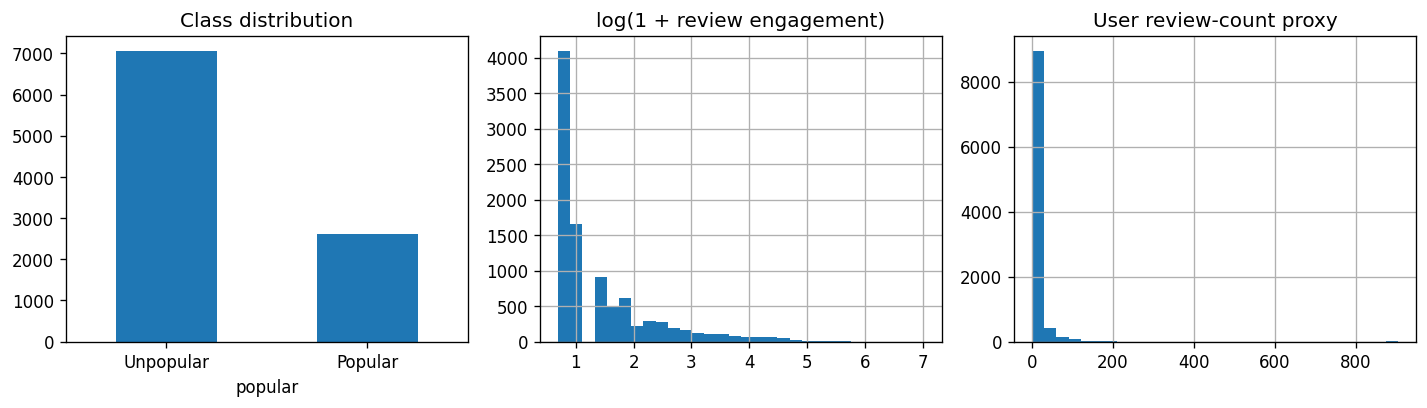

In [10]:
fig, axes = plt.subplots(1,3,figsize=(12,3.5))
dat.popular.value_counts().sort_index().plot.bar(ax=axes[0],rot=0)
axes[0].set_xticklabels(['Unpopular','Popular']); axes[0].set_title('Class distribution')
np.log1p(dat.engagement).hist(bins=30,ax=axes[1]); axes[1].set_title('log(1 + review engagement)')
dat.user_reviews.hist(bins=30,ax=axes[2]); axes[2].set_title('User review-count proxy')
fig.tight_layout(); fig.savefig(OUTPUT/'dataset_overview.png',dpi=160); plt.show(); plt.close(fig)


### 8. Extract text features — Manaswi
`pct_adj` combines adjectives and adverbs, matching upstream code. Sentiment is mean sentence-level VADER compound score. User review count measures positive-engagement reviews in this Poetry snapshot, not a user’s entire history or follower count.

In [11]:
ensure_nltk()
dat = add_features(dat)
display(dat[FEATURE_B+['popular']].head())


Extracted features for 5,000 reviews


,user_reviews,days_since_review,user_rating,rating_diff,num_words,avg_word_len,avg_sent_len,pct_verbs,pct_nouns,pct_adj,quote,sentiment,popular
0,1,34,5,1.04,92,4.326087,13.142857,0.141304,0.391304,0.076087,0,0.105357,0
1,1,1866,5,0.84,143,4.762238,10.214286,0.244755,0.237762,0.153846,0,0.220350,0
2,1,255,2,-1.98,66,3.621212,22.000000,0.212121,0.212121,0.075758,0,-0.165733,0
3,1,392,4,-0.15,2,2.500000,2.000000,0.000000,0.000000,0.000000,0,0.000000,0
4,1,101,3,-1.23,148,4.432432,12.333333,0.182432,0.243243,0.135135,1,0.264700,0


### 9. Freeze train/validation/test splits — teammate
Target book proportions are approximately 70/15/15. Review proportions may differ because books have unequal review counts. No book occurs in two splits. Dataset labels use engagement as the target; direct votes, comments and engagement-share labels are excluded from predictors.
User activity counts come from the full retrospective engaged-review snapshot. Users can occur in multiple book splits; this is not a chronological or user-disjoint forecast.


In [12]:
train, valid, test = split_by_book(dat,SEED)
split_summary = pd.DataFrame([
    dict(split=name,reviews=len(idx),books=dat.iloc[idx].book_id.nunique(),
         popular=int(dat.iloc[idx].popular.sum()),popular_fraction=dat.iloc[idx].popular.mean())
    for name,idx in [('train',train),('validation',valid),('test',test)]])
display(split_summary)
split_summary.to_csv(OUTPUT/'split_summary.csv',index=False)
# Save identifiers only: do not redistribute review text through the repository.
split_ids = pd.concat([dat.iloc[idx][['review_id','book_id']].assign(split=name)
    for name,idx in [('train',train),('validation',valid),('test',test)]])
split_ids.to_csv(OUTPUT/'split_ids.csv',index=False)
train_balanced = balanced_indices(dat.iloc[train].popular,SEED)
print('Balanced training rows:',len(train_balanced))


Balanced training rows: 3766


,split,reviews,books,popular,popular_fraction
0,train,7374,322,1883,0.255357
1,validation,1184,70,374,0.315878
2,test,1105,70,347,0.314027


### 10. Majority baseline — teammate
Use naturally distributed validation/test data. A high accuracy can coexist with zero recall for popular reviews.

In [13]:
from sklearn.dummy import DummyClassifier
dummy=DummyClassifier(strategy='prior').fit(np.zeros((len(train),1)),dat.iloc[train].popular)
baseline=metrics(dat.iloc[test].popular,dummy.predict_proba(np.zeros((len(test),1)))[:,1])
display(pd.DataFrame([baseline]))
(OUTPUT/'baseline.json').write_text(json.dumps(baseline,indent=2))


,accuracy,precision,recall,specificity,f1,roc_auc,average_precision,log_loss,tn,fp,fn,tp
0,0.685973,0.0,0.0,1.0,0.0,0.5,0.314027,0.630936,758,0,347,0


### 11. Run the 18 reference-inspired experiments — Manaswi
A: four metadata features. B: A plus eight writing features. C: B plus BoW. D: B plus TF-IDF. Full and undersampled A/B, undersampled C/D, three model families. Hyperparameters and the winning experiment are selected using validation ROC-AUC only. Test results are reported for comparison; never select the winner using them. MLP epochs use the external validation set for early stopping; it is not an independent second validation set.

In [14]:
results,fitted,best_name,histories,tuning=run_experiments(dat,train,valid,test,MAX_WORDS,SEED)
display(results.sort_values('validation_roc_auc',ascending=False).reset_index(drop=True))
results.to_csv(OUTPUT/'model_results.csv',index=False)
tuning.to_csv(OUTPUT/'validation_tuning.csv',index=False)
(OUTPUT/'neural_network_histories.json').write_text(json.dumps(histories,indent=2))
joblib.dump(fitted[best_name],OUTPUT/'selected_model.joblib')
print('Selected by validation ROC-AUC:',best_name)


LogisticRegression_A_full: validation AUC=0.646, test AUC=0.713
XGBoost_A_full: validation AUC=0.704, test AUC=0.741
NeuralNetwork_A_full: validation AUC=0.698, test AUC=0.732
LogisticRegression_A_undersampled: validation AUC=0.625, test AUC=0.709
XGBoost_A_undersampled: validation AUC=0.687, test AUC=0.730
NeuralNetwork_A_undersampled: validation AUC=0.684, test AUC=0.728
LogisticRegression_B_full: validation AUC=0.672, test AUC=0.736
XGBoost_B_full: validation AUC=0.729, test AUC=0.768
NeuralNetwork_B_full: validation AUC=0.711, test AUC=0.764
LogisticRegression_B_undersampled: validation AUC=0.656, test AUC=0.724
XGBoost_B_undersampled: validation AUC=0.718, test AUC=0.766
NeuralNetwork_B_undersampled: validation AUC=0.692, test AUC=0.746
LogisticRegression_C_undersampled: validation AUC=0.634, test AUC=0.700
XGBoost_C_undersampled: validation AUC=0.724, test AUC=0.770
NeuralNetwork_C_undersampled: validation AUC=0.633, test AUC=0.682
LogisticRegression_D_undersampled: validation AU

,accuracy,precision,recall,specificity,f1,roc_auc,average_precision,log_loss,tn,fp,fn,tp,experiment,family,subset,regime,validation_roc_auc,selected_parameter,training_rows,feature_count,seconds
0,0.752941,0.683168,0.397695,0.915567,0.502732,0.768236,0.627214,0.516237,694,64,209,138,XGBoost_B_full,XGBoost,B,full,0.728953,4.0,7374,12,0.097069
1,0.685068,0.499037,0.746398,0.656992,0.598152,0.770042,0.635033,0.596520,498,260,88,259,XGBoost_C_undersampled,XGBoost,C,undersampled,0.723747,2.0,3766,2012,0.315212
2,0.689593,0.503922,0.740634,0.666227,0.599767,0.774290,0.649178,0.590982,505,253,90,257,XGBoost_D_undersampled,XGBoost,D,undersampled,0.722074,2.0,3766,2012,2.581138
3,0.677828,0.491329,0.734870,0.651715,0.588915,0.766183,0.626792,0.603579,494,264,92,255,XGBoost_B_undersampled,XGBoost,B,undersampled,0.718320,2.0,3766,12,0.073322
4,0.753846,0.714286,0.360231,0.934037,0.478927,0.763993,0.616747,0.523057,708,50,222,125,NeuralNetwork_B_full,NeuralNetwork,B,full,0.711005,32.0,7374,12,1.322764
5,0.736652,0.700000,0.282421,0.944591,0.402464,0.741134,0.589176,0.540483,716,42,249,98,XGBoost_A_full,XGBoost,A,full,0.704333,2.0,7374,4,0.064443
6,0.737557,0.679245,0.311239,0.932718,0.426877,0.731758,0.572622,0.547613,707,51,239,108,NeuralNetwork_A_full,NeuralNetwork,A,full,0.697670,16.0,7374,4,1.192248
7,0.695928,0.511202,0.723343,0.683377,0.599045,0.745801,0.588874,0.616093,518,240,96,251,NeuralNetwork_B_undersampled,NeuralNetwork,B,undersampled,0.692414,16.0,3766,12,0.649690
8,0.661538,0.473373,0.691643,0.647757,0.562061,0.730399,0.558592,0.631845,491,267,107,240,XGBoost_A_undersampled,XGBoost,A,undersampled,0.686591,2.0,3766,4,0.046527
9,0.689593,0.504673,0.622478,0.720317,0.557419,0.727831,0.579892,0.616422,546,212,131,216,NeuralNetwork_A_undersampled,NeuralNetwork,A,undersampled,0.683937,16.0,3766,4,0.654142


### 12. Held-out evaluation and subset B logistic coefficients
The selected model is the one with the best **validation** ROC-AUC. Test scores are used only
to report performance and investigate errors. AUC uses continuous scores, whereas the confusion
matrix uses a fixed 0.5 classification threshold. Sensitivity is recall; specificity is the fraction
of unpopular reviews classified correctly. A high accuracy alone can be misleading with an
imbalanced target, so compare with the majority baseline and inspect recall and ROC-AUC.

LR coefficients describe associations conditional on other included inputs. Positive coefficients
raise the model's log-odds of popularity; negative coefficients lower them. Numeric inputs are
standardized, while word counts/TF-IDF have their own scales. Coefficient magnitude is a useful
ranking within this fitted representation, not proof of causality or a scale-independent ranking.


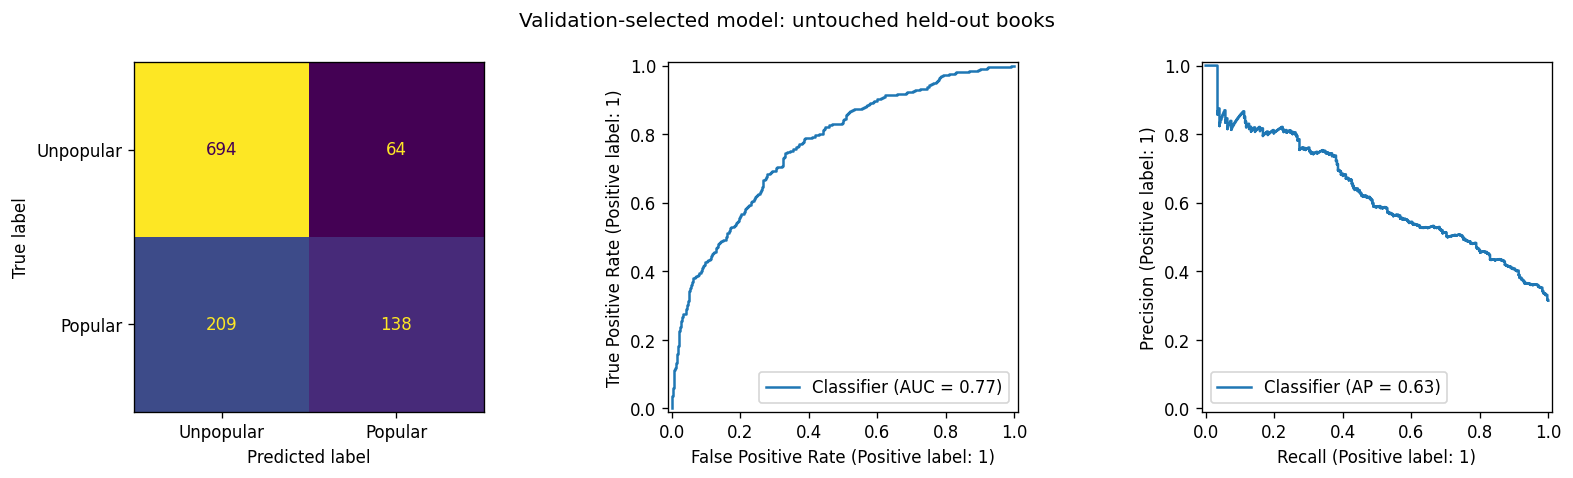

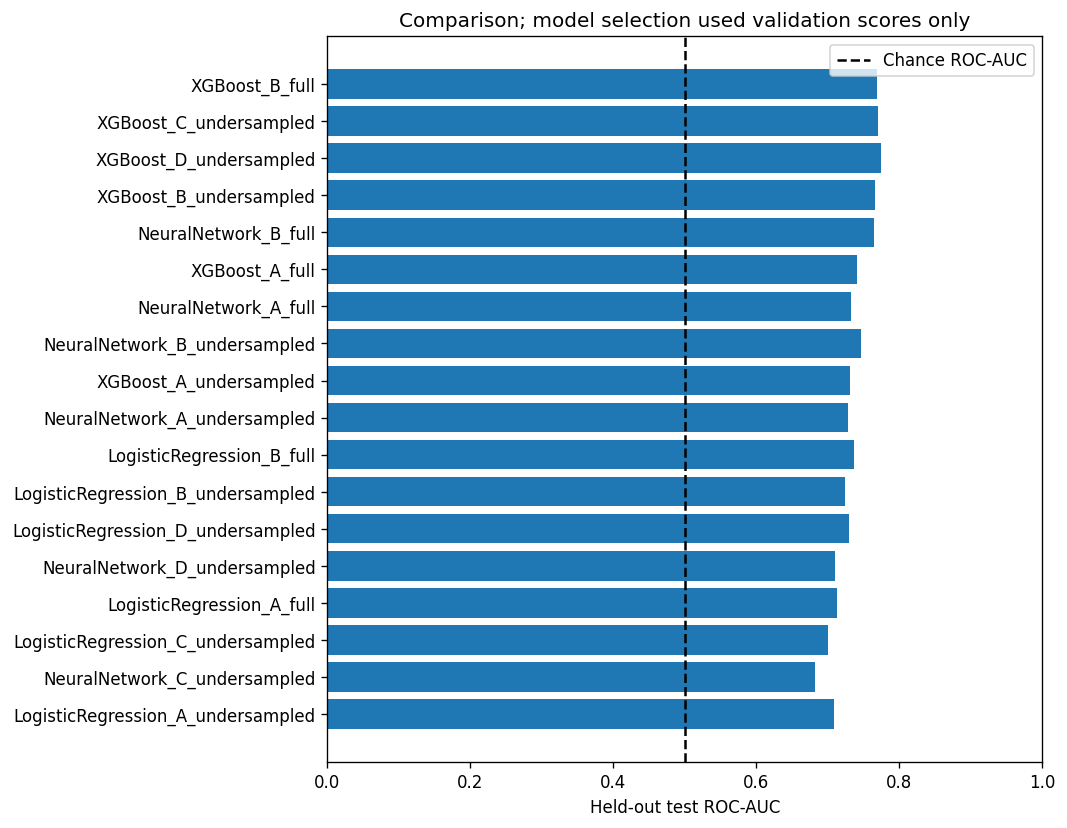

,feature,coefficient,absolute_coefficient
0,user_reviews,0.744761,0.744761
4,num_words,0.450602,0.450602
6,avg_sent_len,0.211140,0.211140
10,quote,0.176552,0.176552
1,days_since_review,0.167160,0.167160
3,rating_diff,-0.125748,0.125748
2,user_rating,0.124422,0.124422
7,pct_verbs,-0.118437,0.118437
11,sentiment,-0.102513,0.102513
9,pct_adj,-0.096467,0.096467


,review_id,book_id,popular,predicted_probability,predicted_label,correct
27,d117619f1d7156addde4226dfc4db0b4,394424,1,0.467877,0,False
100,c6d408d06c3b54e38d2e1506c7543ebb,27822,1,0.176143,0,False
111,2a2d81bcf6fcbff3c6d4dcf545f986d1,2262521,0,0.619385,1,False
235,c5366046db642054b9a892f1172498ee,394424,1,0.486863,0,False
237,e1afd14eef574aec7477330606c67c19,18674286,1,0.101324,0,False
238,9ca4cb7c4fa022bd458567db0453afec,45974,0,0.527228,1,False
247,d06e5becc07131f6c5cd4b00f6db527d,61049,1,0.079121,0,False
325,f1ba310e47cdbdc110f4b495a605bc1b,61049,0,0.630470,1,False
340,d6e137e5386f952482d65ff715226235,18295863,0,0.724317,1,False
386,2a6957e8a9f022248d029f8bf4c5f7b7,768496,1,0.327073,0,False


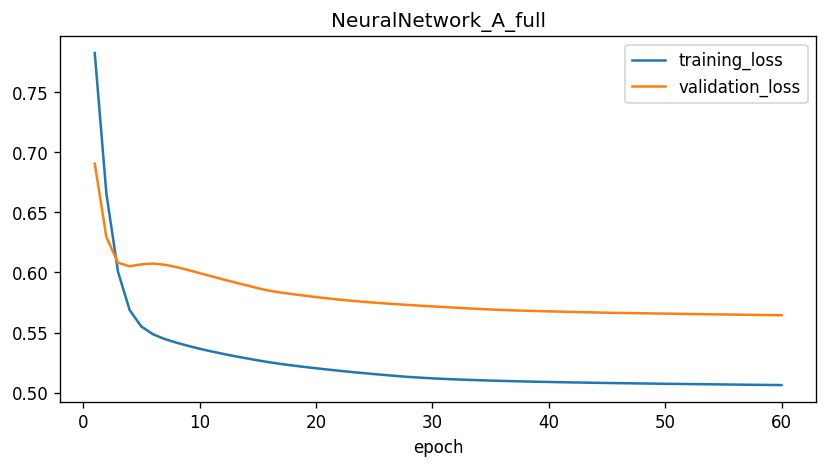

In [15]:
selected=fitted[best_name]
test_probability=selected['model'].predict_proba(selected['transformer'].transform(dat.iloc[test]))[:,1]
save_figures(dat.iloc[test].popular,test_probability,results,OUTPUT)
# Interpretable LR feature ranking for subset B, regardless of the selected family.
lr=fitted['LogisticRegression_B_undersampled']
importance=pd.DataFrame({'feature':FEATURE_B,'coefficient':lr['model'].coef_[0]})
importance['absolute_coefficient']=importance.coefficient.abs()
importance=importance.sort_values('absolute_coefficient',ascending=False)
display(importance); importance.to_csv(OUTPUT/'lr_feature_importance.csv',index=False)
errors=dat.iloc[test][['review_id','book_id','popular']].copy()
errors['predicted_probability']=test_probability
errors['predicted_label']=(test_probability>=.5).astype(int)
errors['correct']=errors.popular==errors.predicted_label
errors.to_csv(OUTPUT/'test_predictions.csv',index=False)
display(errors[~errors.correct].head(10))
if histories:
    name=next(iter(histories)); curve=pd.DataFrame(histories[name])
    ax=curve.plot(x='epoch',y=['training_loss','validation_loss'],title=name,figsize=(7,4))
    ax.figure.tight_layout(); ax.figure.savefig(OUTPUT/'neural_network_learning_curve.png',dpi=160)
    plt.show(); plt.close(ax.figure)


### 12A. Logistic-regression top features and words — paper Table 2
Feature sets: **A** has four metadata features; **B** adds eight linguistic features;
**C** is B plus BoW; **D** is B plus TF-IDF. The following exports include all coefficients
for every LR experiment, not just the best ten. C/D top-ten tables mix numeric features and
words, as in the paper. Separate word-only lists prevent metadata from hiding informative words.

Read the sign as a model association, not advice that adding that word will cause more likes.
BoW values count occurrences; TF-IDF weights reflect frequency and rarity. Numeric inputs are
standardized but individual word columns are not standardized, so C/D magnitudes have different
units. The Poetry subset can produce different words and signs from the full multi-genre paper.

Plot labels put words in quotation marks; `feature_id` in exported tables keeps numeric and word features distinct.


LogisticRegression_C_undersampled — top ten combined features:
LogisticRegression_D_undersampled — top ten combined features:


,feature,feature_type,coefficient
0,user_reviews,numeric,0.805997
1,num_words,numeric,0.623063
2,kaur,word,-0.573496
3,pg,word,-0.511352
4,lovelace,word,-0.504505
5,abuse,word,-0.469098
6,peter,word,0.463163
7,mouth,word,-0.458611
8,sweet,word,-0.453658
9,upon,word,-0.444732


,feature,feature_type,coefficient
0,user_reviews,numeric,0.621858
1,kaur,word,-0.485627
2,part,word,-0.479549
3,num_words,numeric,0.408330
4,poet,word,0.393298
5,collection,word,0.388346
6,honey,word,-0.382085
7,way,word,-0.362841
8,feel,word,-0.359315
9,review,word,0.355422


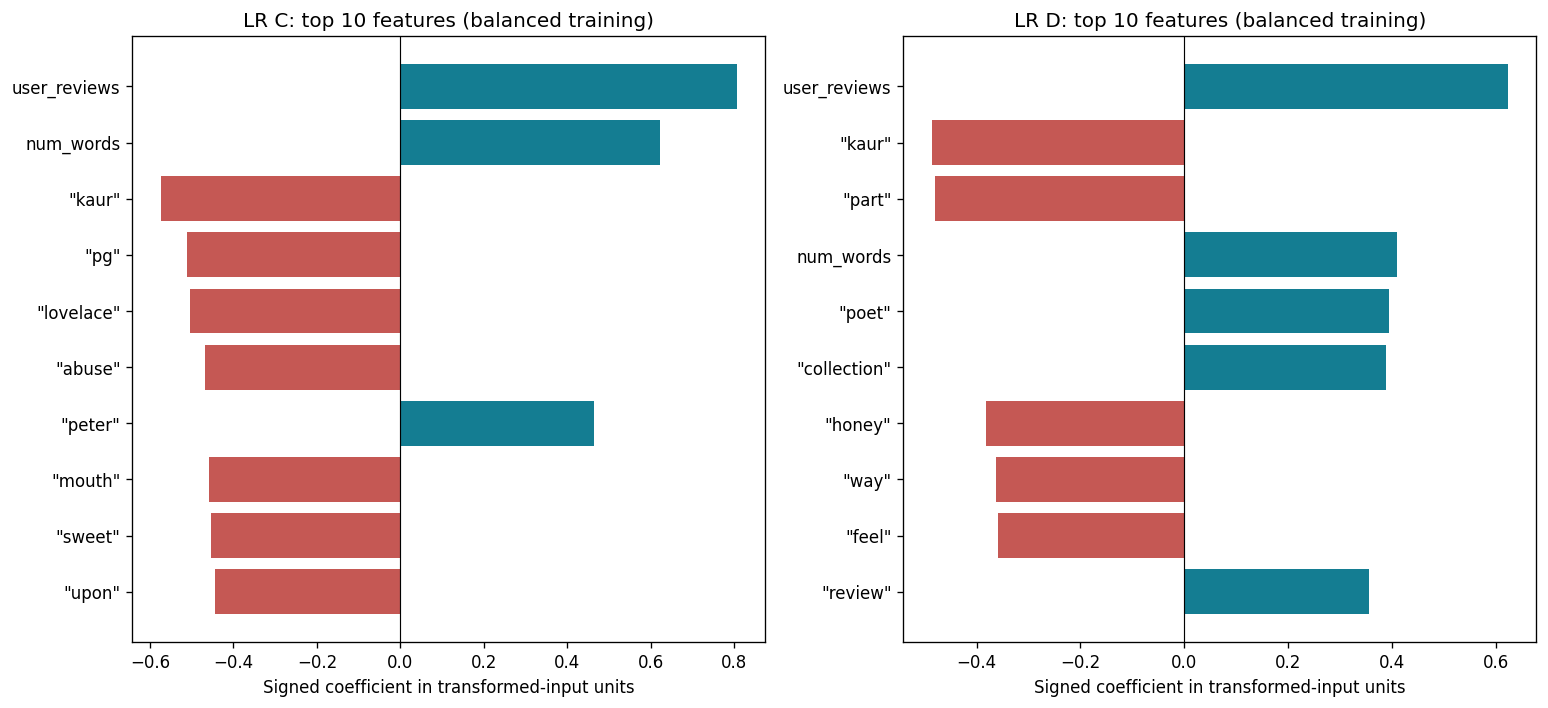

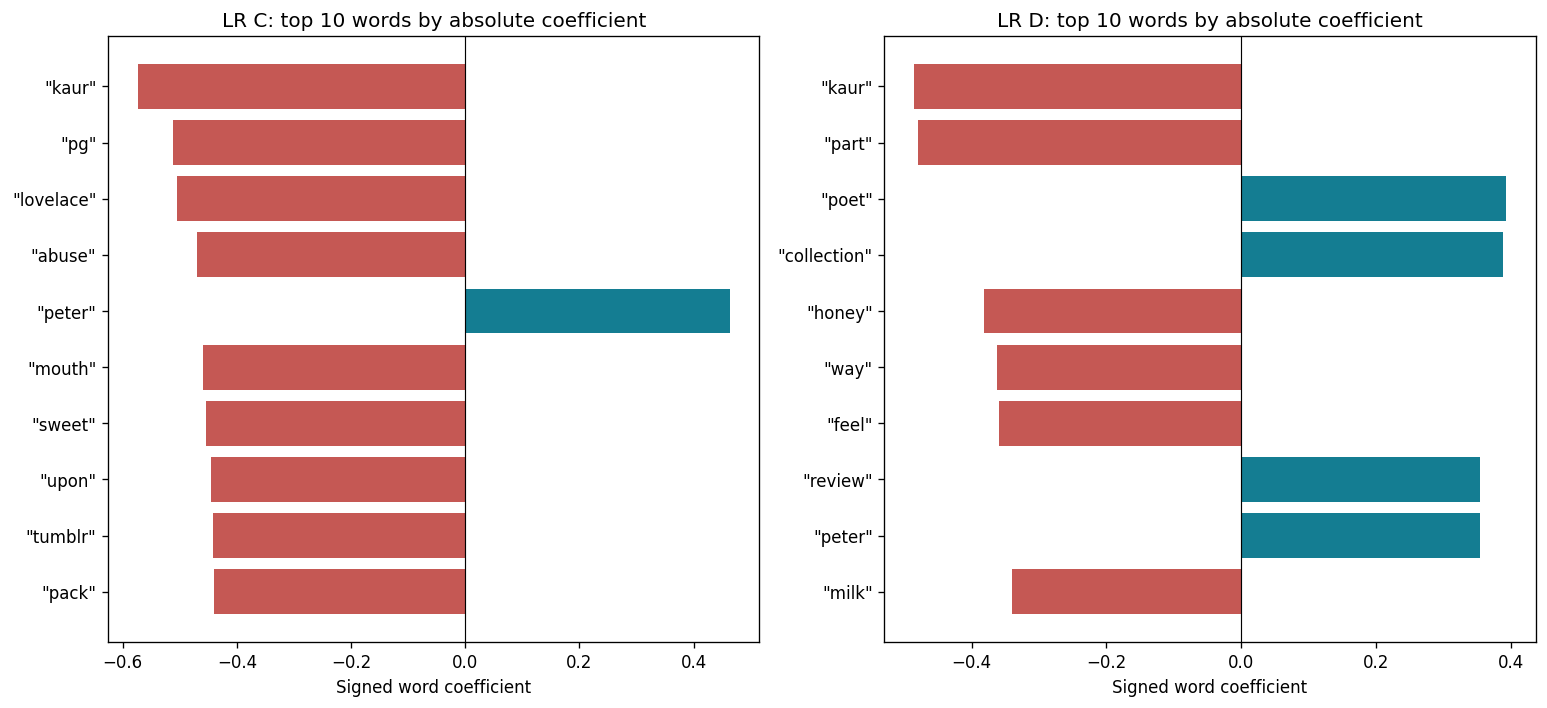

In [16]:
def labelled_features(bundle):
    names = bundle['transformer'].get_feature_names_out()
    return pd.DataFrame({'feature': [str(n).split('__', 1)[-1] for n in names],
                         'feature_id': [str(n) for n in names],
                         'display_feature': [('"' + str(n).split('__',1)[-1] + '"')
                             if str(n).startswith('text__') else str(n).split('__',1)[-1] for n in names],
                         'feature_type': ['word' if str(n).startswith('text__') else 'numeric'
                                          for n in names]})

def finish_plot(fig, filename):
    fig.tight_layout()
    fig.savefig(OUTPUT / filename, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)

coefficient_tables, lr_top_tables, word_tables = [], {}, []
for name, bundle in fitted.items():
    if not name.startswith('LogisticRegression_'):
        continue
    table = labelled_features(bundle)
    table['coefficient'] = bundle['model'].coef_[0]
    table['absolute_coefficient'] = table.coefficient.abs()
    table['experiment'] = name
    table = table.sort_values('absolute_coefficient', ascending=False)
    coefficient_tables.append(table)
    if bundle['subset'] in ['C', 'D']:
        lr_top_tables[bundle['subset']] = table.head(10).reset_index(drop=True)
        words = table[table.feature_type == 'word']
        for direction in ['absolute', 'positive', 'negative']:
            top = (words.head(10) if direction == 'absolute' else
                   words[words.coefficient > 0].nlargest(10, 'coefficient') if direction == 'positive' else
                   words[words.coefficient < 0].nsmallest(10, 'coefficient'))
            word_tables.append(top.assign(ranking=direction))
        print(name, '— top ten combined features:')
        display(lr_top_tables[bundle['subset']][['feature','feature_type','coefficient']])

lr_all = pd.concat(coefficient_tables, ignore_index=True)
lr_all.to_csv(OUTPUT/'lr_coefficients_all_experiments.csv', index=False)
pd.concat(lr_top_tables.values(), ignore_index=True).to_csv(OUTPUT/'lr_top10_C_D.csv', index=False)
lr_words = pd.concat(word_tables, ignore_index=True)
lr_words.to_csv(OUTPUT/'lr_top_words_C_D.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, subset in zip(axes, ['C','D']):
    table = lr_top_tables[subset].iloc[::-1]
    ax.barh(table.display_feature, table.coefficient,
            color=np.where(table.coefficient >= 0, '#147d92', '#c55854'))
    ax.axvline(0, color='black', linewidth=.7)
    ax.set_title(f'LR {subset}: top 10 features (balanced training)')
    ax.set_xlabel('Signed coefficient in transformed-input units')
finish_plot(fig, 'lr_top10_C_D.png')
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, subset in zip(axes, ['C','D']):
    table = lr_words[(lr_words.experiment == f'LogisticRegression_{subset}_undersampled') &
                     (lr_words.ranking == 'absolute')].iloc[::-1]
    ax.barh(table.display_feature, table.coefficient,
            color=np.where(table.coefficient >= 0, '#147d92', '#c55854'))
    ax.axvline(0, color='black', linewidth=.7)
    ax.set_title(f'LR {subset}: top 10 words by absolute coefficient')
    ax.set_xlabel('Signed word coefficient')
finish_plot(fig, 'lr_top_words_C_D.png')


### 12B. XGBoost feature importance — the paper's split-count measure
`weight` is the number of tree splits that use a feature. Features unused by the trees receive
zero. `gain` is the mean loss reduction for those splits and is exported as a supplementary
measure. Split counts show usage, not whether a feature increases or decreases a score.
Do not compare their numerical size with LR coefficients or SHAP values. Correlated inputs
can divide importance between them, and continuous/count inputs can have many candidate splits.

We export every XGBoost model's ranking, plot all A/B/C/D undersampled models and separately
list top C/D words. B's balanced-training plot corresponds to the tree half of paper Figure 1.


XGBoost C: top word features by split count
XGBoost D: top word features by split count


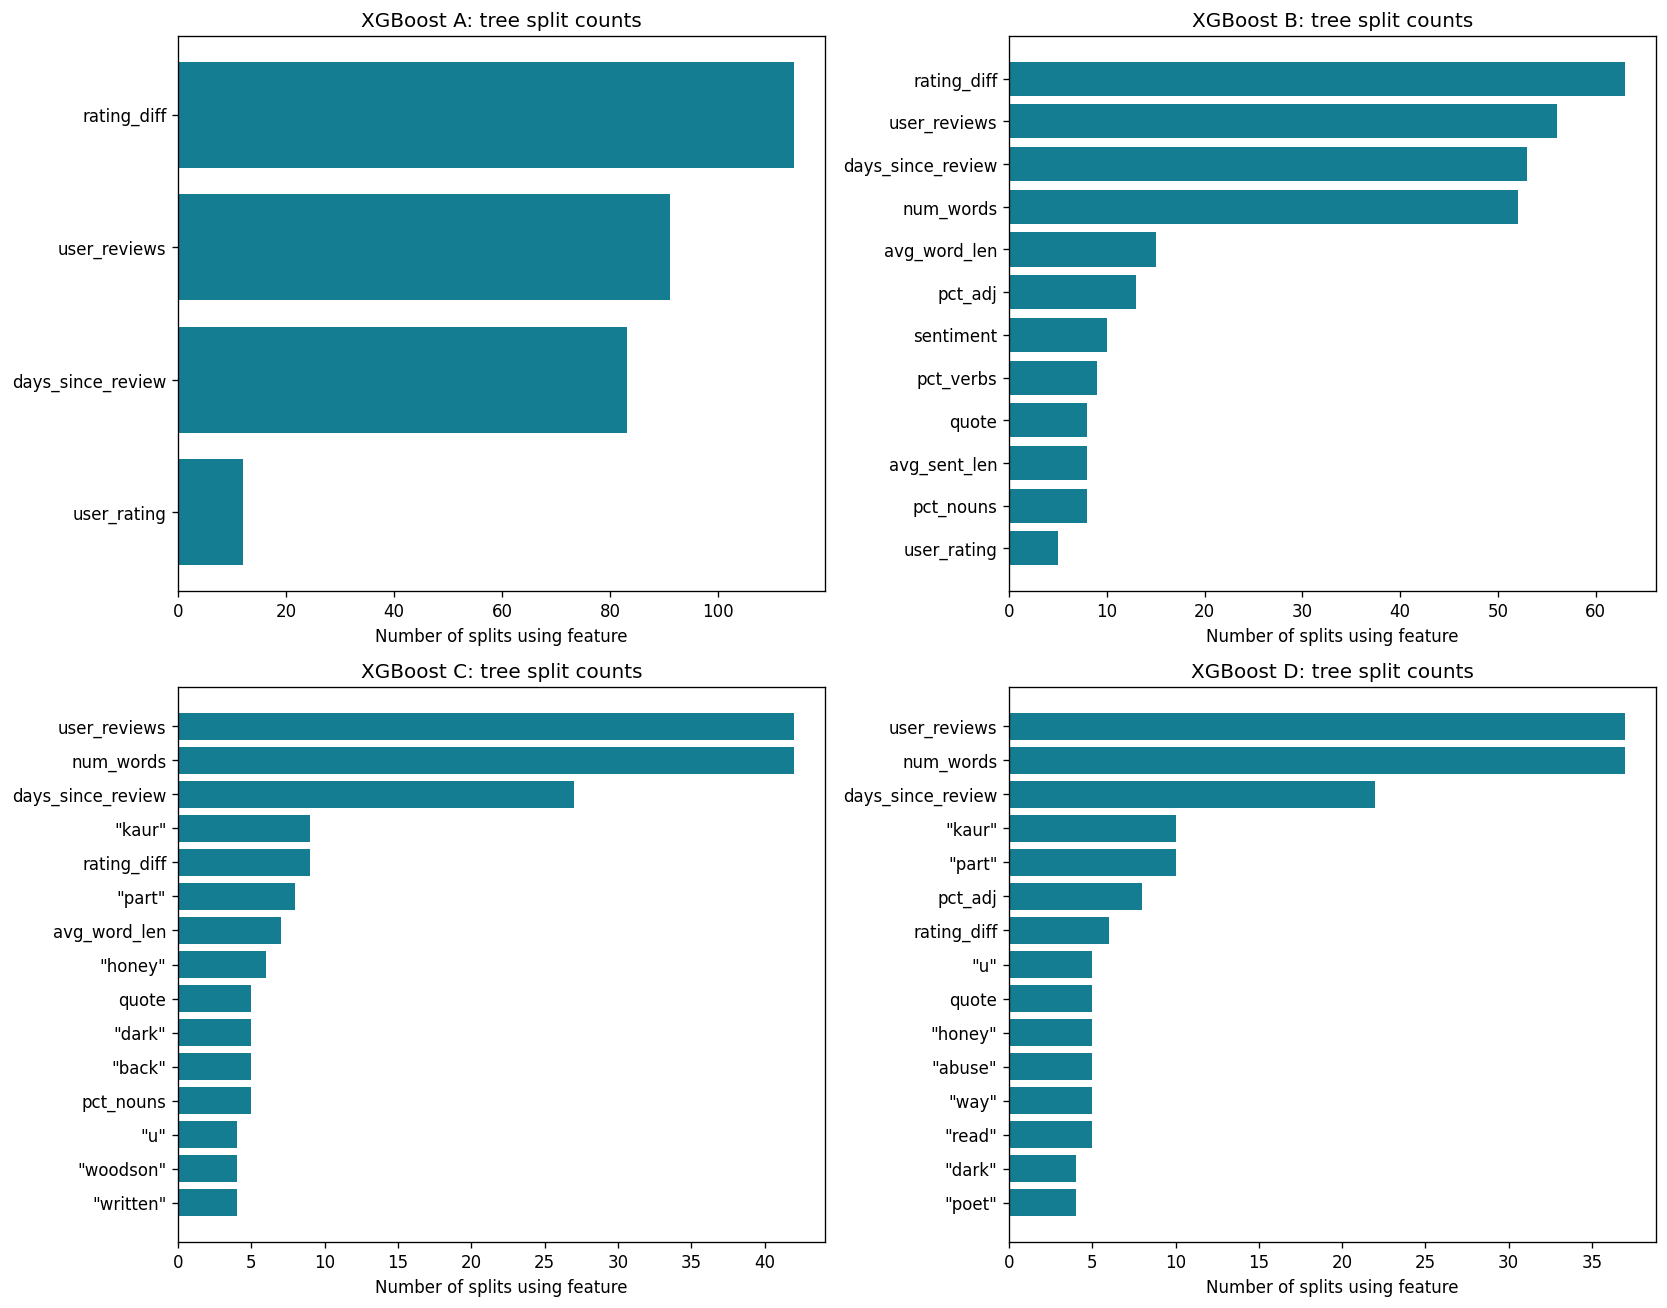

,feature,split_count,mean_gain
942,kaur,9.0,22.682703
1258,part,8.0,11.994257
836,honey,6.0,13.359809
394,dark,5.0,16.115383
132,back,5.0,9.182490
1862,u,4.0,23.424469
1977,woodson,4.0,11.150741
1995,written,4.0,10.090609
1982,world,3.0,21.478102
17,abuse,3.0,15.766870


,feature,split_count,mean_gain
942,kaur,10.0,20.609932
1258,part,10.0,16.272808
1862,u,5.0,23.367357
836,honey,5.0,20.844725
17,abuse,5.0,19.065083
1927,way,5.0,9.941822
1403,read,5.0,2.428206
394,dark,4.0,15.775820
1317,poet,4.0,13.855030
1977,woodson,4.0,13.827909


In [17]:
tree_tables, tree_rankings = [], {}
for name, bundle in fitted.items():
    if not name.startswith('XGBoost_'):
        continue
    table = labelled_features(bundle)
    booster = bundle['model'].get_booster()
    weights = booster.get_score(importance_type='weight')
    gains = booster.get_score(importance_type='gain')
    table['split_count'] = [weights.get(f'f{i}', 0.) for i in range(len(table))]
    table['mean_gain'] = [gains.get(f'f{i}', 0.) for i in range(len(table))]
    table['experiment'] = name
    table = table.sort_values(['split_count','mean_gain'], ascending=False)
    assert table.split_count.sum() > 0, 'Check booster feature naming before interpreting importance.'
    tree_tables.append(table)
    tree_rankings[name] = table
tree_all = pd.concat(tree_tables, ignore_index=True)
tree_all.to_csv(OUTPUT/'xgboost_importance_all_experiments.csv', index=False)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, subset in zip(axes.ravel(), ['A','B','C','D']):
    name = f'XGBoost_{subset}_undersampled'
    table = tree_rankings[name].head(15).iloc[::-1]
    ax.barh(table.display_feature, table.split_count, color='#147d92')
    ax.set_title(f'XGBoost {subset}: tree split counts')
    ax.set_xlabel('Number of splits using feature')
finish_plot(fig, 'xgboost_split_importance_A_B_C_D.png')
tree_word_tables = []
for subset in ['C','D']:
    table = tree_rankings[f'XGBoost_{subset}_undersampled']
    top = table[(table.feature_type == 'word') & (table.split_count > 0)].head(15)
    tree_word_tables.append(top)
    print(f'XGBoost {subset}: top word features by split count')
    display(top[['feature','split_count','mean_gain']])
pd.concat(tree_word_tables, ignore_index=True).to_csv(OUTPUT/'xgboost_top_words_C_D.csv', index=False)


### 12C. Neural-network SHAP explanations for A/B/C/D
[SHAP KernelExplainer documentation](https://shap.readthedocs.io/en/stable/generated/shap.KernelExplainer.html).

SHAP assigns each input a contribution to an individual prediction relative to a training
background. Positive values push the popular-class score up; negative values push it down.
Mean absolute SHAP across explained reviews gives a global ranking for that sample.

The paper used Keras **DeepExplainer**, 5,000 background rows and 1,000 explained predictions.
This notebook retains its small sklearn MLP and uses model-agnostic **KernelExplainer**:
* A: 32 training background rows, 64 test reviews, up to 256 coalition samples per review.
* B: 32 background rows, 100 test reviews, 256 coalition samples per review.
* C/D: 16 background rows, 24 test reviews each, 256 coalition samples per review;
  sparse feature selection keeps up to 20 active contributions per individual explanation.

Samples use fixed seeds and come from balanced training / held-out test sets. Exact sampled IDs,
feature names, attribution arrays, scores, baseline and numerical additivity errors are saved.
Small C/D samples and a limited coalition budget make word rankings **exploratory and less stable**
than the paper's analysis. A zero estimated C/D attribution is not proof that a word has no influence.
These are explanations of this model on transformed inputs, not causal effects or fluent-text edits.
Features are masked independently; correlated or implausible combinations can affect explanations.
SHAP describes the score produced by balanced-training models, not a calibrated real-world probability.

This cell runs automatically. Increase the constants below only if you have time and memory;
the defaults are intended for Colab CPU. Test samples explain existing models; they never retrain them.

In the B beeswarm plot, each dot is one explained review. Red means a larger input value; blue means a smaller value. Dots to the right of zero raise that review's popular-class score.


SHAP A: 64 reviews, 4 features; please wait...
Completed SHAP A; maximum reconstruction error 6e-08
SHAP B: 100 reviews, 12 features; please wait...
Completed SHAP B; maximum reconstruction error 6e-08
SHAP C: 24 reviews, 2012 features; please wait...
Completed SHAP C; maximum reconstruction error 1.2e-07
SHAP D: 24 reviews, 2012 features; please wait...
Completed SHAP D; maximum reconstruction error 6e-08


,feature,feature_type,mean_absolute_shap
0,user_reviews,numeric,0.121598
2,user_rating,numeric,0.054370
1,days_since_review,numeric,0.048374
3,rating_diff,numeric,0.047957


,feature,feature_type,mean_absolute_shap
0,user_reviews,numeric,0.083918
4,num_words,numeric,0.071249
2,user_rating,numeric,0.043438
3,rating_diff,numeric,0.039485
10,quote,numeric,0.025734
1,days_since_review,numeric,0.024857
6,avg_sent_len,numeric,0.019698
5,avg_word_len,numeric,0.017714
11,sentiment,numeric,0.012329
7,pct_verbs,numeric,0.011947


,feature,feature_type,mean_absolute_shap
10,quote,numeric,0.008763
1,days_since_review,numeric,0.004479
1006,life,word,0.003734
1927,way,word,0.002646
17,abuse,word,0.002572
1278,people,word,0.002568
1009,light,word,0.002478
1405,reading,word,0.002214
695,fruit,word,0.002106
1770,text,word,0.002026


,feature,feature_type,mean_absolute_shap
10,quote,numeric,0.031248
1,days_since_review,numeric,0.023662
6,avg_sent_len,numeric,0.019869
7,pct_verbs,numeric,0.017322
0,user_reviews,numeric,0.016983
4,num_words,numeric,0.016814
11,sentiment,numeric,0.013843
9,pct_adj,numeric,0.006201
5,avg_word_len,numeric,0.002599
664,follow,word,0.001689


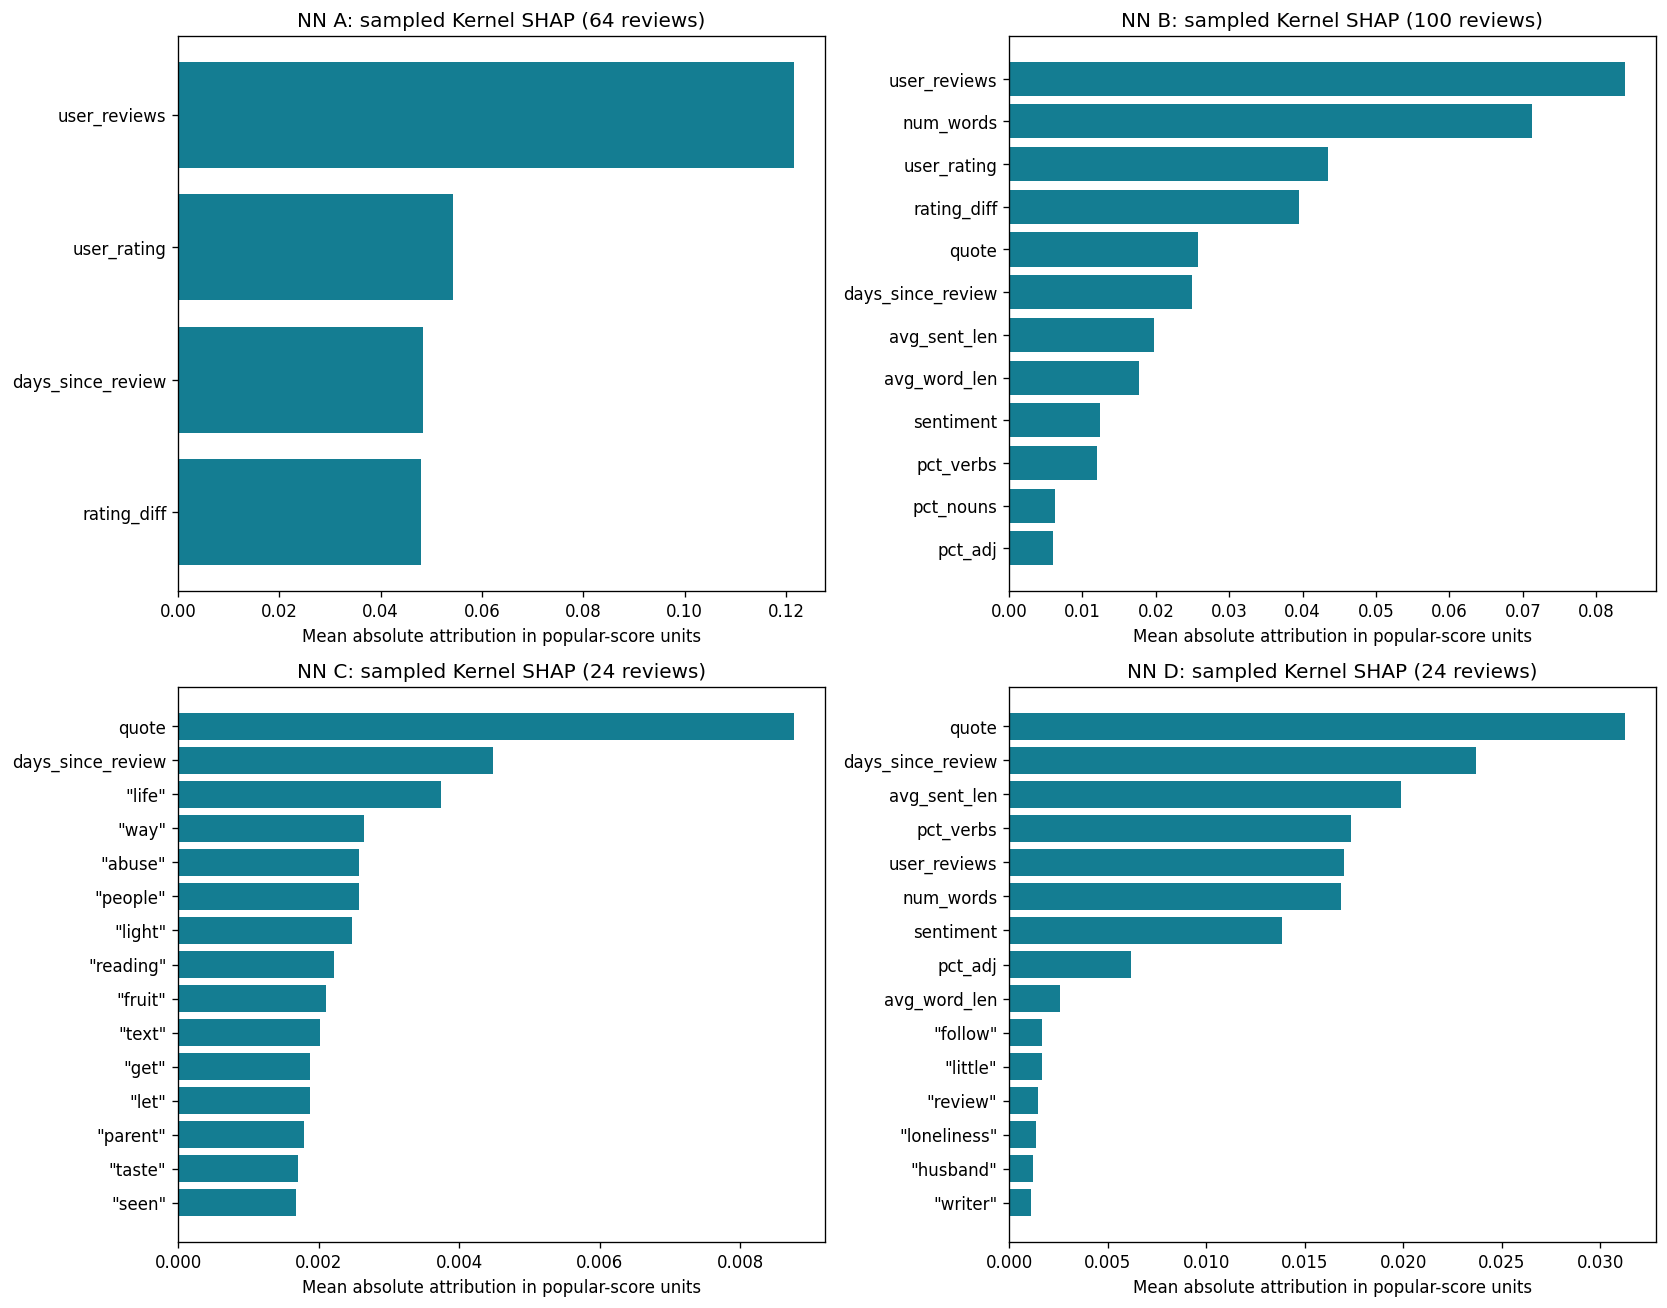

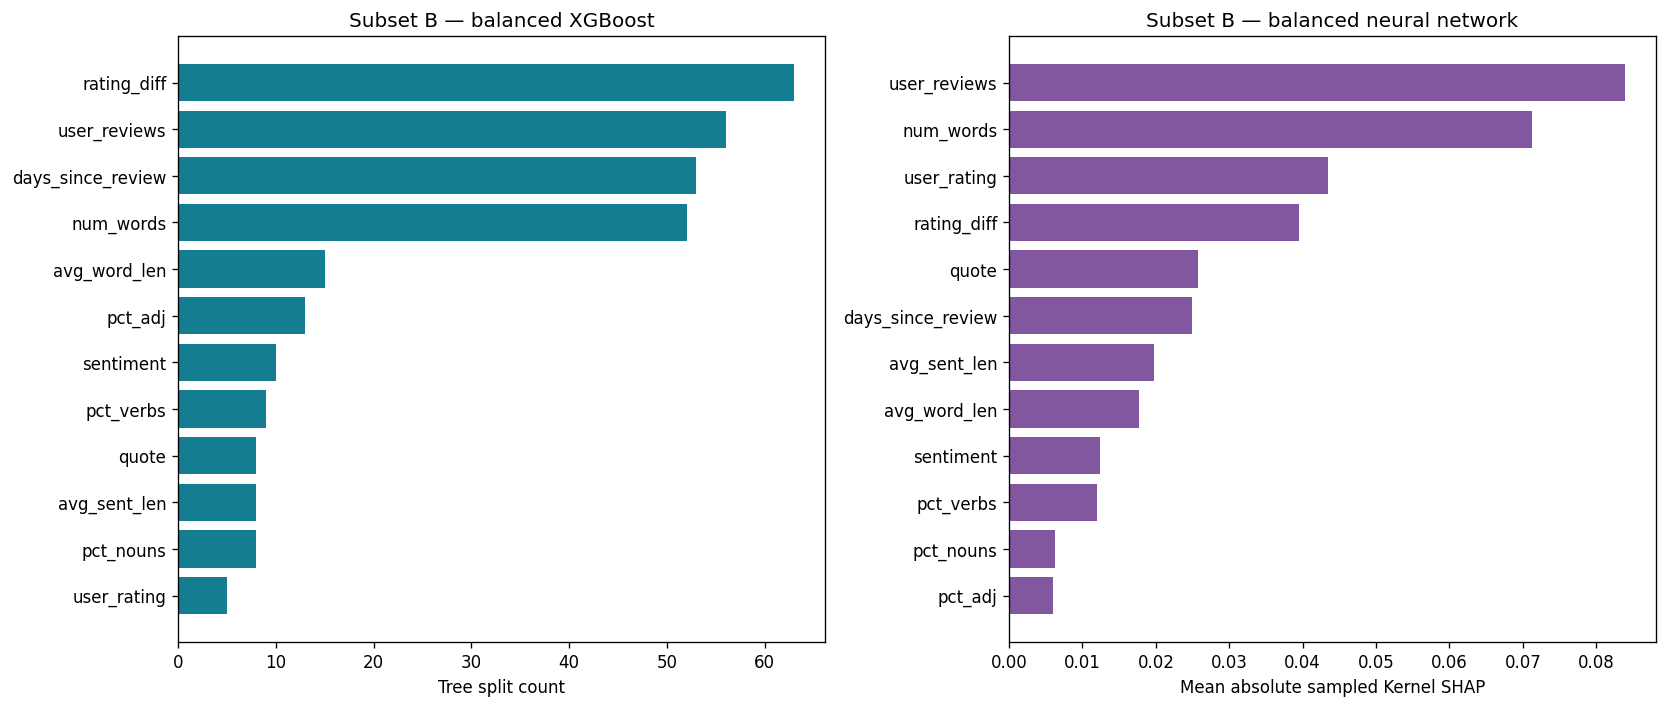

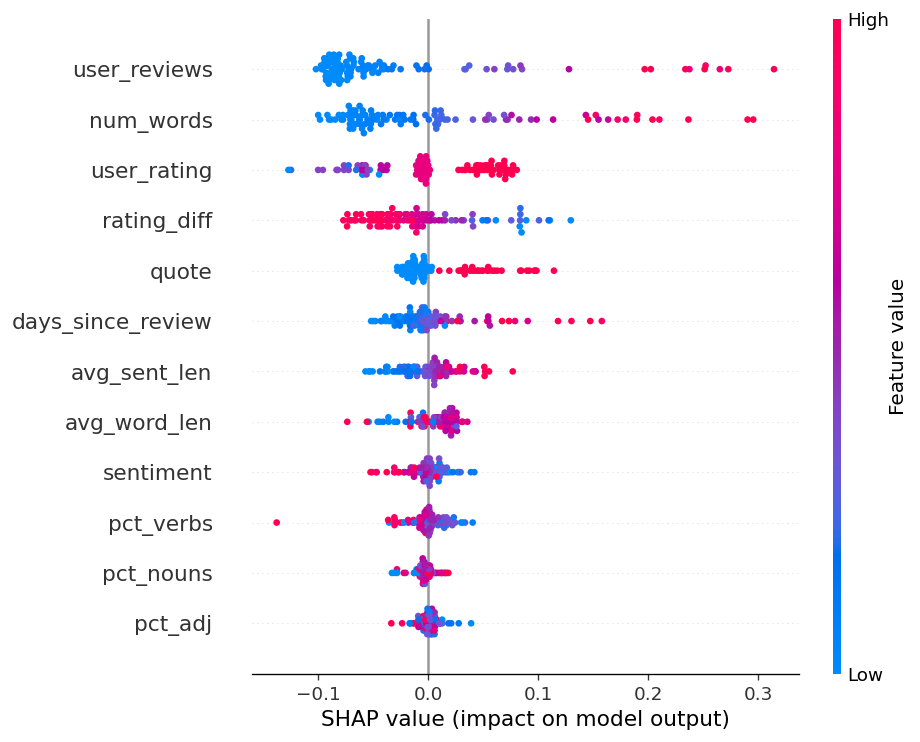

In [18]:
import shap
from threadpoolctl import threadpool_limits

SHAP_CONFIG = {
    'A': dict(background=32, explain=64, nsamples=256),
    'B': dict(background=32, explain=100, nsamples=256),
    'C': dict(background=16, explain=24, nsamples=256),
    'D': dict(background=16, explain=24, nsamples=256),
}
shap_rankings, shap_arrays, shap_checks = {}, {}, []
background_pool = train[train_balanced]
for subset in ['A','B','C','D']:
    name = f'NeuralNetwork_{subset}_undersampled'
    bundle, config = fitted[name], SHAP_CONFIG[subset]
    rng = np.random.default_rng(SEED + ord(subset))
    background_rows = rng.choice(background_pool, min(config['background'], len(background_pool)), replace=False)
    explain_rows = rng.choice(test, min(config['explain'], len(test)), replace=False)
    background = bundle['transformer'].transform(dat.iloc[background_rows])
    explain_x = bundle['transformer'].transform(dat.iloc[explain_rows])
    background = (background.toarray() if sparse.issparse(background) else background).astype(np.float32)
    explain_x = (explain_x.toarray() if sparse.issparse(explain_x) else explain_x).astype(np.float32)
    def positive_score(x, model=bundle['model']):
        # Bounded batches avoid unexpectedly large temporary MLP matrices.
        x = np.asarray(x, dtype=np.float32)
        return np.concatenate([model.predict_proba(x[start:start+1024])[:,1]
                               for start in range(0, len(x), 1024)])
    print(f'SHAP {subset}: {len(explain_x)} reviews, {explain_x.shape[1]} features; please wait...', flush=True)
    started = time.perf_counter()
    previous_random_state = np.random.get_state()
    try:
        np.random.seed(SEED + ord(subset))
        with threadpool_limits(limits=2):
            explainer = shap.KernelExplainer(positive_score, background, link='identity')
            values = np.asarray(explainer.shap_values(explain_x,
                nsamples=config['nsamples'], l1_reg='num_features(20)' if subset in ['C','D'] else 0.,
                silent=True, gc_collect=True))
    finally:
        np.random.set_state(previous_random_state)
    scores = positive_score(explain_x)
    base_value = float(explainer.expected_value)
    residual = np.abs(base_value + values.sum(axis=1) - scores)
    assert values.shape == explain_x.shape and np.isfinite(values).all()
    assert residual.max() < 1e-4, 'SHAP contributions must reconstruct the explained scores.'
    table = labelled_features(bundle)
    table['mean_absolute_shap'] = np.abs(values).mean(axis=0)
    table['mean_signed_shap'] = values.mean(axis=0)
    table['sample_standard_error_abs_shap'] = np.abs(values).std(axis=0, ddof=1)/np.sqrt(len(values))
    table['experiment'] = name
    table = table.sort_values('mean_absolute_shap', ascending=False)
    shap_rankings[subset], shap_arrays[subset] = table, (explain_x, values, base_value)
    table.to_csv(OUTPUT/f'nn_shap_importance_{subset}.csv', index=False)
    np.savez_compressed(OUTPUT/f'nn_shap_samples_{subset}.npz',
        transformed_inputs=explain_x, shap_values=values, base_value=base_value,
        predicted_scores=scores, additivity_residual=residual,
        features=labelled_features(bundle).feature_id.to_numpy(dtype=str),
        test_review_ids=dat.iloc[explain_rows].review_id.to_numpy(dtype=str),
        background_review_ids=dat.iloc[background_rows].review_id.to_numpy(dtype=str))
    shap_checks.append(dict(subset=subset, experiment=name, background_rows=len(background),
        explained_test_rows=len(explain_x), feature_count=explain_x.shape[1], nsamples=config['nsamples'],
        l1_reg='num_features(20)' if subset in ['C','D'] else '0 (no feature selection)',
        base_value=base_value, max_additivity_residual=float(residual.max()),
        seconds=time.perf_counter()-started))
    print(f'Completed SHAP {subset}; maximum reconstruction error {residual.max():.2g}', flush=True)
    display(table.head(10)[['feature','feature_type','mean_absolute_shap']])
pd.DataFrame(shap_checks).to_csv(OUTPUT/'nn_shap_checks.csv', index=False)
pd.concat([shap_rankings[s][shap_rankings[s].feature_type == 'word'].head(15)
           for s in ['C','D']], ignore_index=True).to_csv(OUTPUT/'nn_shap_top_words_C_D.csv', index=False)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, subset in zip(axes.ravel(), ['A','B','C','D']):
    table = shap_rankings[subset].head(15).iloc[::-1]
    ax.barh(table.display_feature, table.mean_absolute_shap, color='#147d92')
    ax.set_title(f'NN {subset}: sampled Kernel SHAP ({SHAP_CONFIG[subset]["explain"]} reviews)')
    ax.set_xlabel('Mean absolute attribution in popular-score units')
finish_plot(fig, 'nn_shap_importance_A_B_C_D.png')
# Paper Figure 1 analogue: rankings use different measures, so keep separate axes.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
tree_b = tree_rankings['XGBoost_B_undersampled'].iloc[::-1]
nn_b = shap_rankings['B'].iloc[::-1]
axes[0].barh(tree_b.display_feature, tree_b.split_count, color='#147d92')
axes[0].set_title('Subset B — balanced XGBoost')
axes[0].set_xlabel('Tree split count')
axes[1].barh(nn_b.display_feature, nn_b.mean_absolute_shap, color='#8356a0')
axes[1].set_title('Subset B — balanced neural network')
axes[1].set_xlabel('Mean absolute sampled Kernel SHAP')
finish_plot(fig, 'paper_figure1_subset_B.png')
# Signed per-review view makes direction visible; high input values are red.
inputs_b, values_b, baseline_b = shap_arrays['B']
plt.figure(figsize=(9, 6))
shap.summary_plot(values_b, inputs_b, feature_names=labelled_features(fitted['NeuralNetwork_B_undersampled']).feature.tolist(),
                  max_display=12, show=False, rng=np.random.default_rng(SEED))
finish_plot(plt.gcf(), 'nn_shap_B_beeswarm.png')


### 12D. Predicted scores versus actual engagement share
The paper inspected whether binary-classifier scores tracked the continuous engagement share.
Here Pearson correlation measures linear association and Spearman measures rank association for
**all 18 models**, including the paper's LR-B and XGBoost-D balanced examples.
The scatter plots use a log x-axis so small shares remain visible; correlation is computed on
the original share, not the log values. The vertical line is the label cutoff 0.02 and the
horizontal line is the classification-score cutoff 0.5; these are different quantities.

A classifier score of 0.7 does **not** mean that a review earns 70% of its book's engagement.
Correlation is descriptive; a binary classifier is not a trained engagement-share regressor.
Undersampling changes the training prevalence, so those scores should not be read as calibrated
probabilities. The paper's correlations (about 0.29 and 0.33) are context, not targets to match.


,experiment,test_rows,pearson_r,spearman_rho
0,LogisticRegression_A_full,1105,0.333492,0.412126
1,XGBoost_A_full,1105,0.396637,0.463051
2,NeuralNetwork_A_full,1105,0.394458,0.436837
3,LogisticRegression_A_undersampled,1105,0.343778,0.412728
4,XGBoost_A_undersampled,1105,0.358377,0.455227
5,NeuralNetwork_A_undersampled,1105,0.370804,0.432054
6,LogisticRegression_B_full,1105,0.401915,0.437626
7,XGBoost_B_full,1105,0.418644,0.470000
8,NeuralNetwork_B_full,1105,0.431027,0.460299
9,LogisticRegression_B_undersampled,1105,0.366072,0.413494


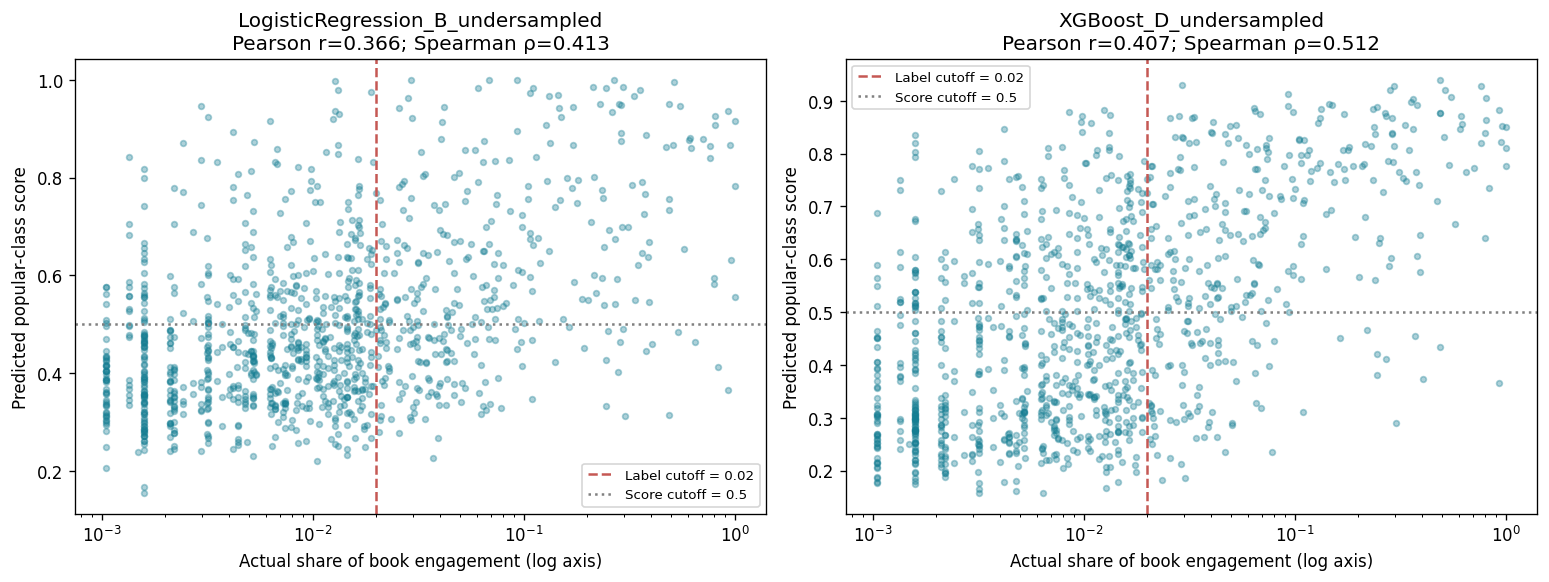

In [19]:
from scipy.stats import pearsonr, spearmanr
share = dat.iloc[test].like_share.to_numpy()
all_test_scores, correlations = {}, []
for name, bundle in fitted.items():
    scores = bundle['model'].predict_proba(bundle['transformer'].transform(dat.iloc[test]))[:,1]
    assert np.isfinite(scores).all() and ((scores >= 0) & (scores <= 1)).all()
    all_test_scores[name] = scores
    constant = np.ptp(scores) == 0
    correlations.append(dict(experiment=name, test_rows=len(scores),
        pearson_r=np.nan if constant else float(pearsonr(share, scores).statistic),
        spearman_rho=np.nan if constant else float(spearmanr(share, scores).statistic)))
correlation_table = pd.DataFrame(correlations)
correlation_table.to_csv(OUTPUT/'prediction_engagement_correlations.csv', index=False)
display(correlation_table)
score_export = dat.iloc[test][['review_id','book_id','popular','like_share']].reset_index(drop=True).copy()
for name, scores in all_test_scores.items():
    score_export[name] = scores
score_export.to_csv(OUTPUT/'all_model_test_scores.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name in zip(axes, ['LogisticRegression_B_undersampled','XGBoost_D_undersampled']):
    row = correlation_table[correlation_table.experiment == name].iloc[0]
    ax.scatter(share, all_test_scores[name], s=12, alpha=.35, color='#147d92', rasterized=True)
    ax.set_xscale('log')
    ax.axvline(.02, color='#c55854', linestyle='--', label='Label cutoff = 0.02')
    ax.axhline(.5, color='gray', linestyle=':', label='Score cutoff = 0.5')
    ax.set_xlabel('Actual share of book engagement (log axis)')
    ax.set_ylabel('Predicted popular-class score')
    ax.set_title(f'{name}\nPearson r={row.pearson_r:.3f}; Spearman ρ={row.spearman_rho:.3f}')
    ax.legend(fontsize=8)
finish_plot(fig, 'prediction_vs_engagement_share.png')


### 12E. Feature distributions by error group — TP / FP / FN / TN
**TP:** popular and predicted popular. **FP:** unpopular but predicted popular.
**FN:** popular but missed. **TN:** unpopular and predicted unpopular.
This recreates the reference repository's prediction investigation for balanced LR-B and adds
the validation-selected model. Group counts, feature summaries and distribution plots are saved
for all 12 B features plus actual share and model score. No review text is exported.

The ECDF is the fraction of a group's reviews below each x-value: curves farther to the right
indicate larger values. Counts, ages and lengths use log(1+x) for plotting only, not for training
or the saved summaries. Compare TP with FN to inspect missed popular reviews; compare TP with FP
to inspect false alarms. If curves overlap, that feature alone does not clearly separate them.
These are descriptive groups partly defined by the model itself, not independent causal tests.


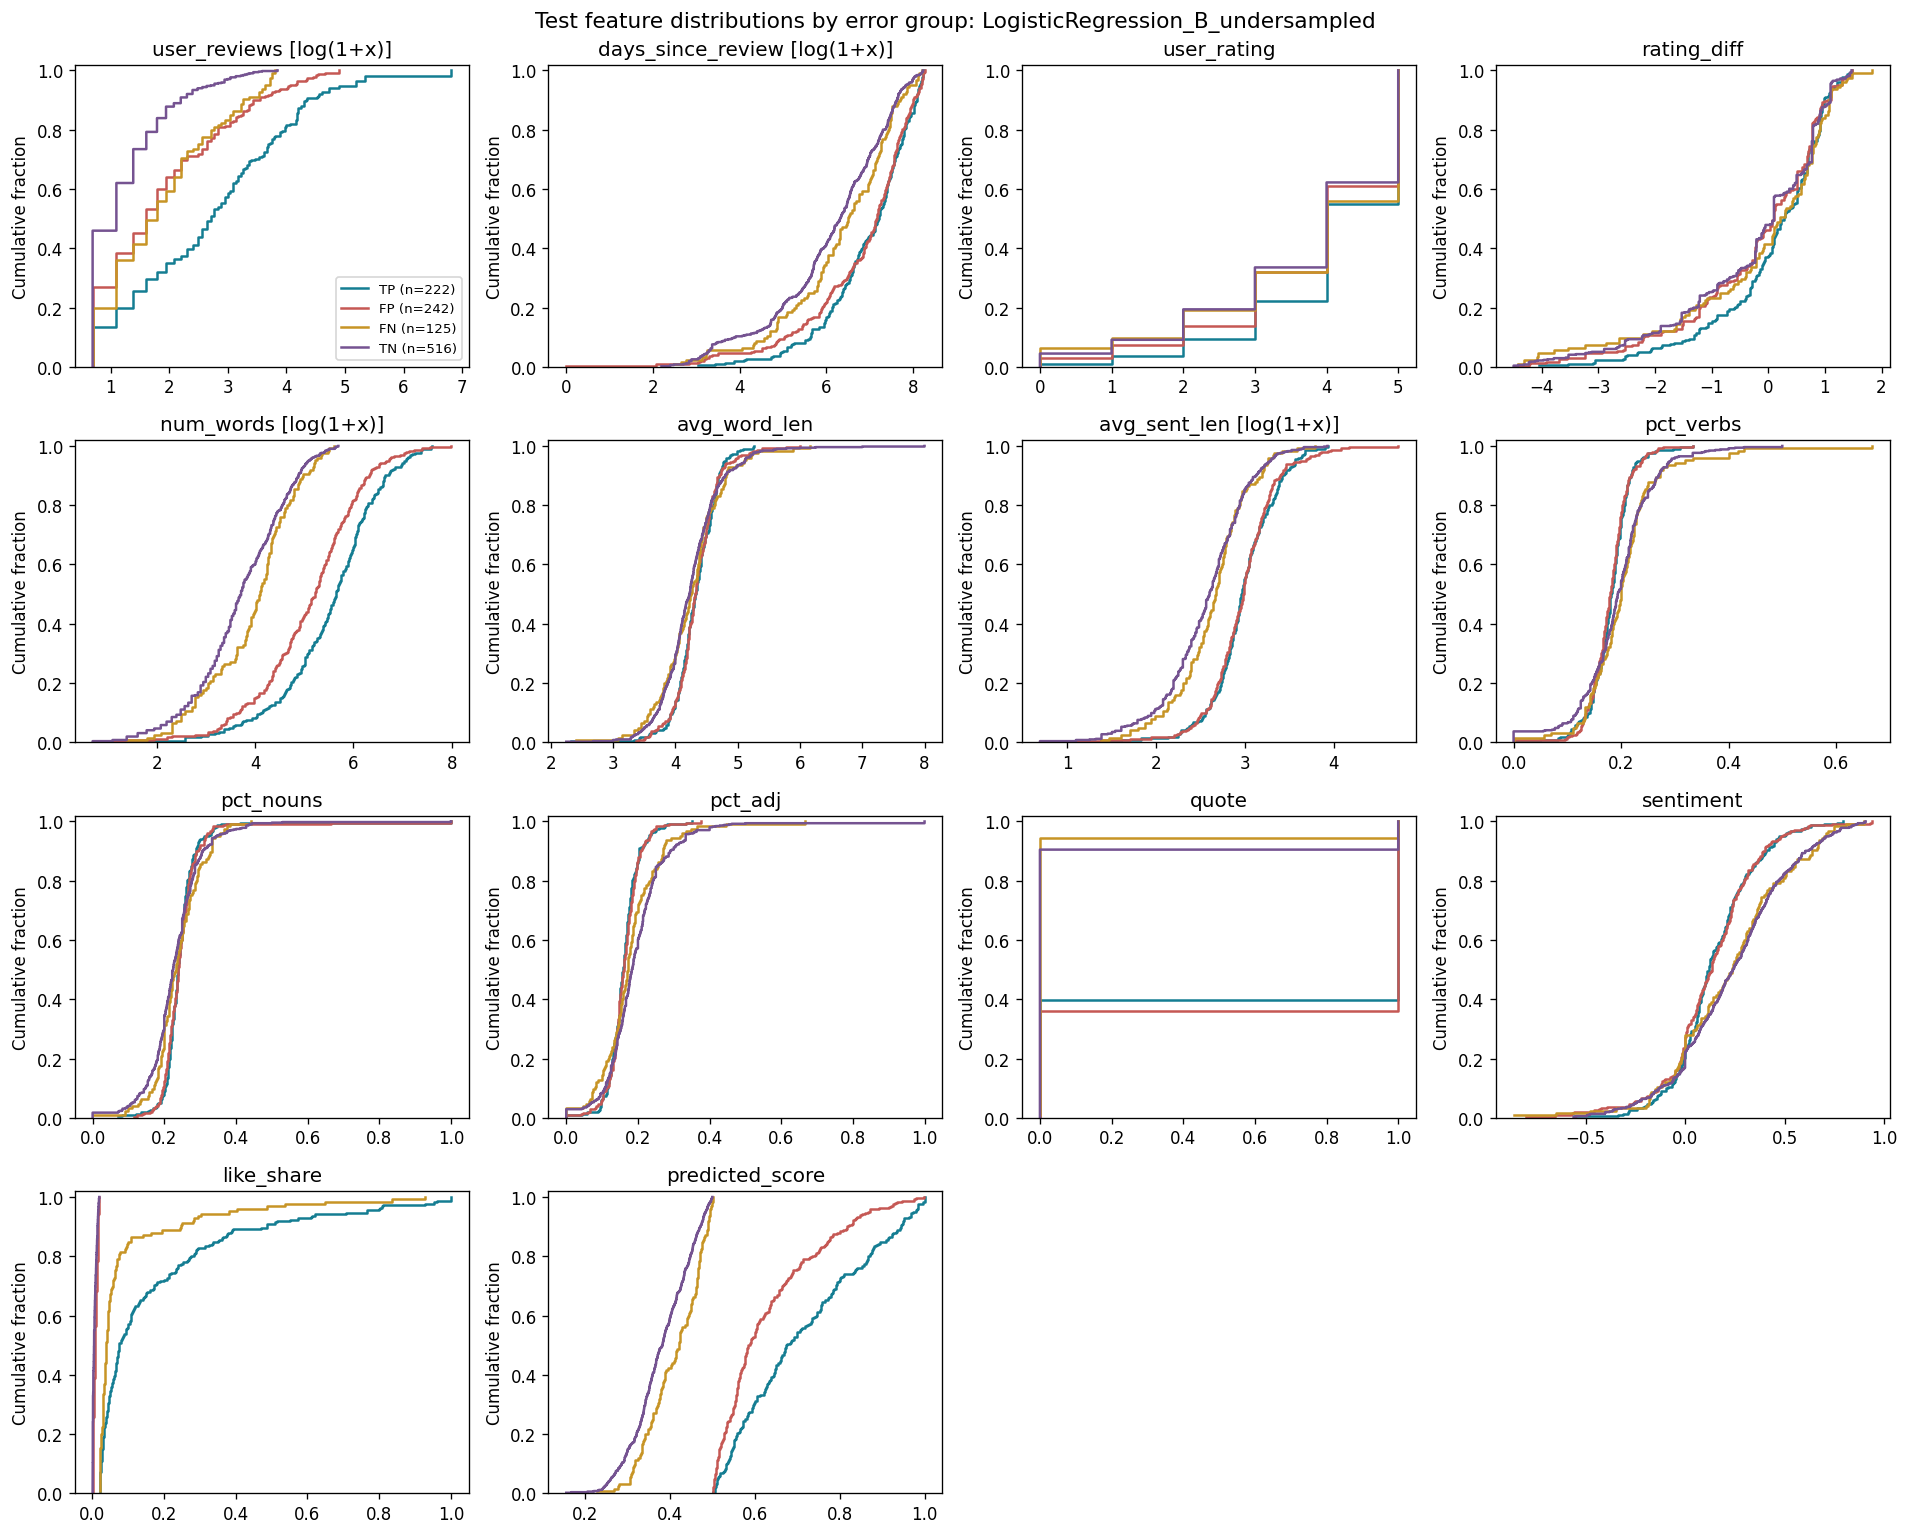

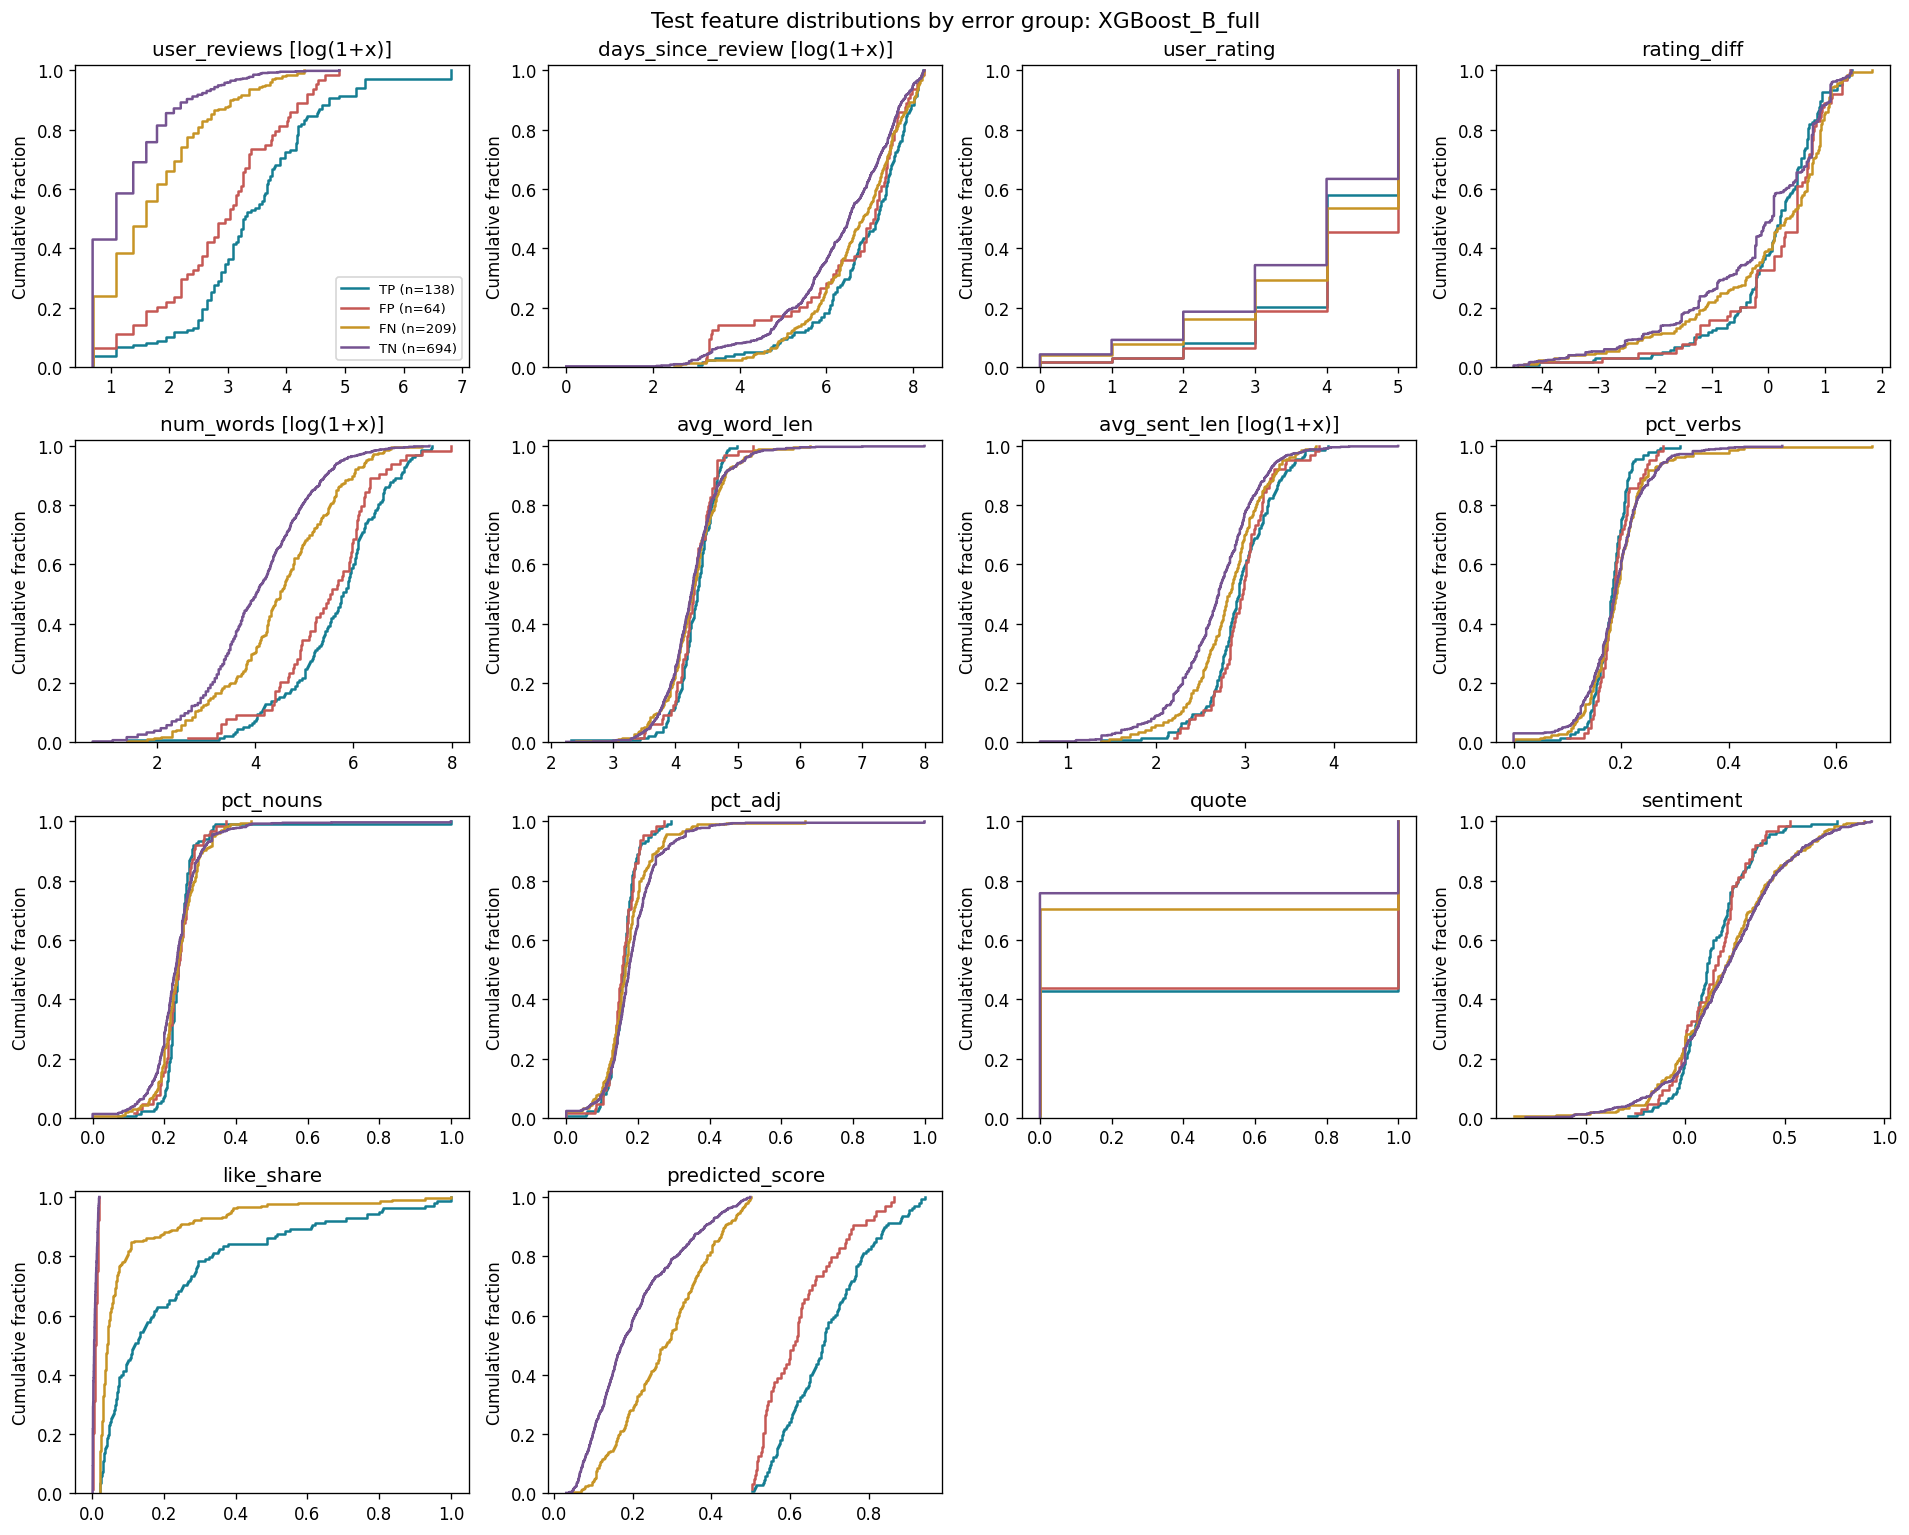

,experiment,error_group,reviews
0,LogisticRegression_B_undersampled,TP,222
1,LogisticRegression_B_undersampled,FP,242
2,LogisticRegression_B_undersampled,FN,125
3,LogisticRegression_B_undersampled,TN,516
4,XGBoost_B_full,TP,138
5,XGBoost_B_full,FP,64
6,XGBoost_B_full,FN,209
7,XGBoost_B_full,TN,694


,experiment,error_group,feature,n,mean,std,median,q25,q75
0,LogisticRegression_B_undersampled,TP,user_reviews,222,45.103604,123.684290,14.00,3.0000,39.00
3,LogisticRegression_B_undersampled,TP,rating_diff,222,0.043153,1.030055,0.27,-0.3200,0.77
4,LogisticRegression_B_undersampled,TP,num_words,222,378.126126,353.083998,282.50,140.5000,473.25
14,LogisticRegression_B_undersampled,FP,user_reviews,242,12.347107,21.197045,4.00,1.0000,13.00
17,LogisticRegression_B_undersampled,FP,rating_diff,242,-0.221405,1.254392,0.10,-0.9000,0.77
18,LogisticRegression_B_undersampled,FP,num_words,242,265.483471,318.458648,183.50,81.2500,328.00
28,LogisticRegression_B_undersampled,FN,user_reviews,125,9.232000,11.134179,5.00,2.0000,11.00
31,LogisticRegression_B_undersampled,FN,rating_diff,125,-0.201840,1.445086,0.21,-0.7100,0.83
32,LogisticRegression_B_undersampled,FN,num_words,125,70.096000,55.642062,59.00,27.0000,89.00
42,LogisticRegression_B_undersampled,TN,user_reviews,516,3.639535,5.280290,2.00,1.0000,4.00


In [20]:
GROUP_ORDER = ['TP','FP','FN','TN']
GROUP_COLORS = {'TP':'#147d92','FP':'#c55854','FN':'#c79425','TN':'#755391'}
error_frames, error_summaries, error_counts = [], [], []
error_models = list(dict.fromkeys(['LogisticRegression_B_undersampled', best_name]))
error_features = FEATURE_B + ['like_share','predicted_score']
log_features = {'user_reviews','days_since_review','num_words','avg_sent_len'}
for name in error_models:
    frame = dat.iloc[test][['review_id','book_id','popular','like_share'] + FEATURE_B].reset_index(drop=True).copy()
    frame['predicted_score'] = all_test_scores[name]
    predicted = frame.predicted_score >= .5
    actual = frame.popular == 1
    frame['error_group'] = np.select([actual & predicted, ~actual & predicted,
                                    actual & ~predicted, ~actual & ~predicted],
                                   GROUP_ORDER, default='INVALID')
    frame['experiment'] = name
    assert not (frame.error_group == 'INVALID').any()
    counts = frame.error_group.value_counts().reindex(GROUP_ORDER, fill_value=0)
    metric_row = metrics(frame.popular, frame.predicted_score)
    for group in GROUP_ORDER:
        assert counts[group] == metric_row[group.lower()]
        error_counts.append(dict(experiment=name, error_group=group, reviews=int(counts[group])))
        group_rows = frame[frame.error_group == group]
        for feature in error_features:
            series = group_rows[feature]
            error_summaries.append(dict(experiment=name, error_group=group, feature=feature,
                n=len(series), mean=series.mean(), std=series.std(), median=series.median(),
                q25=series.quantile(.25), q75=series.quantile(.75)))
    error_frames.append(frame)
    fig, axes = plt.subplots(4, 4, figsize=(16, 13))
    for ax, feature in zip(axes.ravel(), error_features):
        for group in GROUP_ORDER:
            x = np.sort(frame.loc[frame.error_group == group, feature].to_numpy())
            if not len(x):
                continue
            if feature in log_features:
                x = np.log1p(x)
            ax.step(x, np.arange(1, len(x)+1)/len(x), where='post', color=GROUP_COLORS[group],
                    label=f'{group} (n={counts[group]})', linewidth=1.5)
        ax.set_title(feature + (' [log(1+x)]' if feature in log_features else ''))
        ax.set_ylabel('Cumulative fraction'); ax.set_ylim(0, 1.02)
    for ax in axes.ravel()[len(error_features):]:
        ax.set_visible(False)
    axes[0,0].legend(fontsize=8)
    fig.suptitle(f'Test feature distributions by error group: {name}', fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, .97])
    finish_plot(fig, f'error_feature_distributions_{name}.png')
pd.concat(error_frames, ignore_index=True).to_csv(OUTPUT/'error_group_review_features.csv', index=False)
pd.DataFrame(error_summaries).to_csv(OUTPUT/'error_group_feature_summary.csv', index=False)
error_count_table = pd.DataFrame(error_counts)
error_count_table.to_csv(OUTPUT/'error_group_counts.csv', index=False)
display(error_count_table)
display(pd.DataFrame(error_summaries).query("feature in ['user_reviews','num_words','rating_diff']"))


### 12F. Read the results and relate them to the paper
The cell below generates a short factual interpretation from this run's outputs. It reports
what the models learned on Poetry rather than copying conclusions from the paper.
Feature rankings can disagree because each family learns a different function and uses a different
importance measure. Differences between BoW and TF-IDF are empirical observations on this split.

For your report, compare: (1) balanced versus full training accuracy and recall; (2) A versus B to
assess linguistic features; (3) B versus C/D to assess vocabulary; (4) user activity versus text
importance; (5) the paper's qualitative conclusions versus your actual output. These comparisons
do not isolate causal effects and must not be used to select a new model on the test set.


In [21]:
winner = results[results.experiment == best_name].iloc[0]
discussion = [
    f'Scope: {len(dat):,} English Poetry reviews, {dat.book_id.nunique():,} books; '
    f'{dat.popular.mean():.1%} popular under the >0.02 engagement-share rule.',
    f'Validation selected {best_name}. Test ROC-AUC={winner.roc_auc:.3f}, '
    f'accuracy={winner.accuracy:.3f}, recall={winner.recall:.3f}, specificity={winner.specificity:.3f}.',
    f'Majority baseline: accuracy={baseline["accuracy"]:.3f}, ROC-AUC={baseline["roc_auc"]:.3f}, '
    f'recall={baseline["recall"]:.3f}. Interpret these jointly, not accuracy alone.',
]
for family in ['LogisticRegression','XGBoost','NeuralNetwork']:
    full = results[results.experiment == f'{family}_B_full'].iloc[0]
    balanced = results[results.experiment == f'{family}_B_undersampled'].iloc[0]
    discussion.append(f'{family} B, full -> balanced training: accuracy {full.accuracy:.3f} -> '
        f'{balanced.accuracy:.3f}; recall {full.recall:.3f} -> {balanced.recall:.3f}; '
        f'ROC-AUC {full.roc_auc:.3f} -> {balanced.roc_auc:.3f}.')
for subset in ['C','D']:
    discussion.append(f'LR {subset} top absolute coefficients: ' + ', '.join(lr_top_tables[subset].display_feature.head(5)) + '.')
    discussion.append(f'XGBoost {subset} top split-count features: ' +
        ', '.join(tree_rankings[f'XGBoost_{subset}_undersampled'].display_feature.head(5)) + '.')
    discussion.append(f'NN {subset} top sampled SHAP features: ' + ', '.join(shap_rankings[subset].display_feature.head(5)) +
        '. These high-dimensional SHAP ranks are exploratory.')
for feature in ['user_reviews','user_rating','rating_diff','num_words','sentiment']:
    coefficient = float(lr_all[(lr_all.experiment == 'LogisticRegression_B_undersampled') &
                               (lr_all.feature == feature)].coefficient.iloc[0])
    discussion.append(f'LR B {feature}: coefficient {coefficient:+.3f} '
                      '(conditional association in standardized units; not causation).')
for name in ['LogisticRegression_B_undersampled','XGBoost_D_undersampled']:
    row = correlation_table[correlation_table.experiment == name].iloc[0]
    discussion.append(f'{name}: score/share Pearson r={row.pearson_r:.3f}, Spearman rho={row.spearman_rho:.3f}.')
for name in error_models:
    counts = error_count_table[error_count_table.experiment == name]
    discussion.append(f'{name} errors: ' + ', '.join(f'{r.error_group}={r.reviews}' for r in counts.itertuples()) + '.')
discussion += [
    'Inspect the saved error ECDF plots before claiming that a feature separates TP, FP or FN. '
    'Overlapping curves do not establish identical groups or causality.',
    'Poetry user activity is a subset count; the paper used a much larger multi-genre snapshot. '
    'Different importance rankings are expected and should be discussed.',
    'This is broad paper-inspired analytical coverage on a reduced dataset, not exact experimental parity.',
]
discussion_text = '\n\n'.join(discussion)
print(discussion_text)
(OUTPUT/'results_interpretation.txt').write_text(discussion_text, encoding='utf-8')


Scope: 9,663 English Poetry reviews, 462 books; 26.9% popular under the >0.02 engagement-share rule.

Validation selected XGBoost_B_full. Test ROC-AUC=0.768, accuracy=0.753, recall=0.398, specificity=0.916.

Majority baseline: accuracy=0.686, ROC-AUC=0.500, recall=0.000. Interpret these jointly, not accuracy alone.

LogisticRegression B, full -> balanced training: accuracy 0.727 -> 0.668; recall 0.231 -> 0.640; ROC-AUC 0.736 -> 0.724.

XGBoost B, full -> balanced training: accuracy 0.753 -> 0.678; recall 0.398 -> 0.735; ROC-AUC 0.768 -> 0.766.

NeuralNetwork B, full -> balanced training: accuracy 0.754 -> 0.696; recall 0.360 -> 0.723; ROC-AUC 0.764 -> 0.746.

LR C top absolute coefficients: user_reviews, num_words, "kaur", "pg", "lovelace".

XGBoost C top split-count features: user_reviews, num_words, days_since_review, "kaur", rating_diff.

NN C top sampled SHAP features: quote, days_since_review, "life", "way", "abuse". These high-dimensional SHAP ranks are exploratory.

LR D top abs

### 13. Text-only demonstration — Manaswi
A supplementary TF-IDF logistic model accepts a fresh review without invented user/book metadata. Its score is a model output, not a calibrated guarantee of future popularity. The comparison models using metadata require those metadata inputs.

In [22]:
from sklearn.pipeline import make_pipeline
demo_candidates=[]
for c in [.1,1.]:
    demo_model=make_pipeline(TfidfVectorizer(max_features=MAX_WORDS,min_df=2,
        token_pattern=r'(?u)\b\w+\b'),LogisticRegression(C=c,solver='liblinear',max_iter=1000,random_state=SEED))
    demo_model.fit(dat.iloc[train].processed_text.iloc[train_balanced],
                   dat.iloc[train].popular.iloc[train_balanced])
    val_score=roc_auc_score(dat.iloc[valid].popular,demo_model.predict_proba(dat.iloc[valid].processed_text)[:,1])
    demo_candidates.append((val_score,c,demo_model))
demo_val,demo_c,demo_model=max(demo_candidates,key=lambda x:x[0])
demo_scores=demo_model.predict_proba(dat.iloc[test].processed_text)[:,1]
demo_metrics=metrics(dat.iloc[test].popular,demo_scores)
demo_metrics.update(validation_roc_auc=float(demo_val),selected_C=demo_c)
(OUTPUT/'demo_metrics.json').write_text(json.dumps(demo_metrics,indent=2))
joblib.dump(demo_model,OUTPUT/'text_demo.joblib')
display(pd.DataFrame([demo_metrics]))
def predict_review(review):
    if not isinstance(review,str) or not review.strip():
        raise ValueError('Enter a non-empty review.')
    text=extract_text_features(review)['processed_text']
    if not text:
        raise ValueError('The review must contain meaningful words.')
    score=float(demo_model.predict_proba([text])[0,1])
    return {'prediction':'Popular' if score>=.5 else 'Unpopular','model_score':round(score,4),
            'scope':'Goodreads Poetry; retrospective engagement label; uncalibrated score'}
display(predict_review('The imagery is memorable, but the collection repeats the same ideas.'))
# Check persistence: the loaded normal sklearn pipeline gives identical scores.
loaded_demo=joblib.load(OUTPUT/'text_demo.joblib')
assert np.allclose(loaded_demo.predict_proba(dat.iloc[test].processed_text)[:,1],demo_scores)


,accuracy,precision,recall,specificity,f1,roc_auc,average_precision,log_loss,tn,fp,fn,tp,validation_roc_auc,selected_C
0,0.626244,0.440647,0.706052,0.58971,0.542636,0.695235,0.528824,0.664282,447,311,102,245,0.640929,0.1


{'prediction': 'Popular', 'model_score': 0.5019, 'scope': 'Goodreads Poetry; retrospective engagement label; uncalibrated score'}

### 14. Reproducibility record and honest conclusions — both members

In [23]:
versions={name:importlib.metadata.version(name) for name in
    ['numpy','pandas','scipy','scikit-learn','xgboost','nltk','fasttext','joblib','matplotlib','shap','numba','threadpoolctl']}
summary={'dataset_scope':'Goodreads Poetry subset','raw_reviews':int(audit.iloc[0].reviews),
         'final_reviews':len(dat),'books':int(dat.book_id.nunique()),'users':int(dat.user_id.nunique()),
         'popular_reviews':int(dat.popular.sum()),'popular_fraction':float(dat.popular.mean()),
         'best_experiment_selected_by_validation':best_name,
         'selected_test_metrics':metrics(dat.iloc[test].popular,test_probability),
         'majority_baseline':baseline,'text_only_demo':demo_metrics,
         'seed':SEED,'max_words':MAX_WORDS,'versions':versions,
         'paper_reference_commit':'5297102c0dd9cb93145fd0b1fdf3bf63532bab6a',
         'input_sha256':metadata['input_sha256'],
         'shap_config':SHAP_CONFIG,'shap_checks':shap_checks,
         'explanations':['LR coefficients all six experiments and C/D word rankings',
            'XGBoost split counts all six experiments and C/D word rankings',
            'Sampled Kernel SHAP for balanced NN A/B/C/D',
            'Score/share correlations all 18 experiments',
            'All 12 B feature distributions by TP/FP/FN/TN for LR B and selected model'],
         'limitations':['Single genre; results do not establish general performance.',
           'Snapshot review counts and age are retrospective metadata.',
           'Scores after undersampling are not calibrated probabilities.',
           'Vocabulary, architecture, splitting and tuning differ from the full paper.',
           'Snapshot engagement is affected by exposure and reviewer following; no causal claims.']}
(OUTPUT/'run_summary.json').write_text(json.dumps(summary,indent=2))
print(json.dumps(summary,indent=2))

# Capture resources and runtime details; fixed seeds/pins do not imply cross-hardware bitwise identity.
summary['runtime'] = dict(python=platform.python_version(), platform=platform.platform(),
    threads={k:os.environ.get(k) for k in ['OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS']})
summary['fasttext_model_sha256'] = digest(ensure_language_model(ROOT))
(OUTPUT/'run_summary.json').write_text(json.dumps(summary, indent=2))
(OUTPUT/'requirements.txt').write_text(REQUIREMENTS, encoding='utf-8')
pd.Series(versions, name='version').rename_axis('package').to_csv(OUTPUT/'package_versions.csv')


{
  "dataset_scope": "Goodreads Poetry subset",
  "raw_reviews": 154555,
  "final_reviews": 9663,
  "books": 462,
  "users": 6336,
  "popular_reviews": 2604,
  "popular_fraction": 0.2694815274759392,
  "best_experiment_selected_by_validation": "XGBoost_B_full",
  "selected_test_metrics": {
    "accuracy": 0.7529411764705882,
    "precision": 0.6831683168316832,
    "recall": 0.3976945244956772,
    "specificity": 0.9155672823218998,
    "f1": 0.5027322404371585,
    "roc_auc": 0.7682358398029092,
    "average_precision": 0.6272141443093456,
    "log_loss": 0.5162367099359405,
    "tn": 694,
    "fp": 64,
    "fn": 209,
    "tp": 138
  },
  "majority_baseline": {
    "accuracy": 0.685972850678733,
    "precision": 0.0,
    "recall": 0.0,
    "specificity": 1.0,
    "f1": 0.0,
    "roc_auc": 0.5,
    "average_precision": 0.31402714932126696,
    "log_loss": 0.6309356274443909,
    "tn": 758,
    "fp": 0,
    "fn": 347,
    "tp": 0
  },
  "text_only_demo": {
    "accuracy": 0.626244343891

### 15. Download your results
Allow the browser download. This ZIP contains your generated metrics, plots and fitted models.

In [24]:
# Save results before closing Colab. Raw datasets and language resources are excluded.
import shutil

archive_path = shutil.make_archive(str(ROOT / 'Book_Review_Popularity_Results'),
                                   'zip', root_dir=ROOT, base_dir='results')
print('Completed. Results ZIP:', archive_path)
print('Also use File > Download > Download .ipynb to save this notebook with your outputs.')
if IN_COLAB:
    from google.colab import files
    files.download(archive_path)


Completed. Results ZIP: /workspace/scratch/379881d459e3/final_validation/Book_Review_Popularity_Results.zip
Also use File > Download > Download .ipynb to save this notebook with your outputs.


### Paper coverage and honest remaining differences
| Paper component | This notebook |
|---|---|
| Engagement-share label, >0.02 | Implemented; book totals precede language filtering |
| Review/book eligibility and English filtering | Implemented using metadata counts and official fastText; invalid negative counts excluded |
| Feature sets A/B/C/D | Implemented; default 2,000-word BoW/TF-IDF vocabulary |
| Three families, full/undersampled comparison | All 18 experiment combinations implemented |
| Accuracy, sensitivity, specificity, ROC-AUC | Implemented; plus precision, F1, AP, log-loss, ROC/PR plots and baseline |
| LR top-ten combined features and word rankings | Implemented for C/D; complete LR coefficients exported |
| XGBoost split-count importance | Implemented for all tree models; C/D words and B comparison plot |
| NN SHAP and word rankings | Implemented for balanced A/B/C/D with smaller Kernel SHAP samples |
| Score versus continuous engagement share | Pearson/Spearman for all 18; paper-example scatter plots |
| Feature distributions by prediction/error group | All B inputs plus share/score; LR-B and validation-selected model |

**Remaining differences are material:** the paper used approximately 1.98 million filtered reviews
across genres, random review splits and 10,000+ word representations. Here Poetry has about 9,663
filtered reviews; splits hold out entire books and features/word vocabulary fit training rows only.
The reference's A/B LR was unregularized/unscaled; this adaptation uses scaled, L2-regularized LR.
Its larger XGBoost grid and up to 1,000 trees are reduced to 100 trees with two depth candidates.
The paper's Keras network dimensions/layers and early stopping differ from this small sklearn MLP.
SHAP uses a different explainer and much smaller samples, especially C/D. The data cleaning,
date reference and boundary details are documented in preprocessing comments. Scores may differ
slightly with hardware or resource versions despite fixed seeds and pinned core packages.

The paper/code's reported AUC cannot be compared as an identical benchmark: its evaluation often
uses rounded class predictions, whereas this notebook computes ROC-AUC from continuous scores.
Present the work as **“An extended adaptation of book review popularity prediction on the Goodreads
Poetry subset”**, and explain these differences. Do not claim the original dataset, architecture,
reported numerical results or complete experimental reproduction.

### Two-person completion plan (60% / 40%)
| Person | Ownership and genuine work to complete |
|---|---|
| Manaswi — 60% | Feature extraction and A/B/C/D representations; 18 model experiments/tuning; LR/tree/NN SHAP implementation and interpretation; integration, rerun and live model demo |
| Teammate — 40% | Dataset upload/filter audit; split/leakage checks; baseline and evaluation; correlation/error-group validation and explanation; results plots, README/report/slides and packaging |
Both review the final outputs and understand the full pipeline. Commit actual work under each
person's own GitHub account as it is completed; do not fabricate past contribution history.
Suggested real commit sequence: teammate `audit poetry inputs and filtering`; Manaswi `build features
and compare classifiers`; teammate `validate held-out evaluation and errors`; Manaswi `add feature
rankings and sampled SHAP`; teammate `document findings and paper differences`; both review a final
`verify Colab run and submission files` commit. For work already supplied here, credit the adaptation
and make genuine review/documentation contributions rather than presenting generated code as original.

### Minimal GitHub contents
Keep this **executed notebook**, a README, the generated `requirements.txt`, your lab report PDF,
and requested slides. Add compact result CSVs/figures that support report claims; the ZIP is only
a download convenience. Heavy datasets, fastText/NLTK resources and model binaries need not be committed.
Do not upload raw review text. Existing source scripts can remain if your README identifies this
notebook as the entry point. Before submission, fill in your teammate's actual name/SRN and verify
that report claims match your own final run.


### Submission handoff
- Private GitHub repository; faculty/TA access; verified README setup/run instructions.
- PDF write-up: problem, dataset, method, implementation and actual conclusions.
  Guidelines conflict (one-page heading vs two-page body); prepare a concise two-page draft and confirm.
- Slide deck and mandatory live demo; both explain their actual contributions.
- Do not commit raw Goodreads data, downloaded language models or copied review texts.
- Generated source is a starting implementation. Make genuine adaptations, execute it yourselves,
  preserve attribution and follow your course's rules on external code / AI assistance.
